## Исследование регистрируемой безработицы в России.

<b>Задача:</b>
Для составления аналитического обзора по проблеме безработицы в России необходимо провести исследование основных социально-демографических характеристик безработных и ситуацию в 2020 году.<br>

<b>Источник данных:</b><br>
Регистрируемая безработица в России: общие социально-демографические характеристики с детализацией до органа занятости населения // Роструд; обработка: Колесников И.В., Копыток В.К., Кузьмина Ю.В., Инфраструктура научно-исследовательских данных, АНО «ЦПУР», 2021. Доступ: открытая лицензия в исследовательских целях. Размещено: 21.10.2021. (Ссылка на набор данных: http://data-in.ru/data-catalog/datasets/180/)

<b>Описание данных:</b><br>

## <b>Задание:</b>

### <a class="anchor" id="1"></a> Загрузка данных. Предобработка

In [7]:
#импортируем библиотеку пандас
import pandas as pd
#загрузим данные
df = pd.read_csv('unemployed.csv', sep = ';')

In [8]:
#определим размер датасета
df.shape

(4347416, 12)

In [9]:
#предпросмотр данных
df.head()

,id,district,region,month_application,changed_value,age,gender,education,hc_repeat,hc_didnotwork,find_new_job,count
0,1170,Дальневосточный федеральный округ,Амурская область,2017-01,False,52-57,0.0,4.0,True,False,False,1
1,256,Дальневосточный федеральный округ,Амурская область,2017-01,False,22-27,1.0,4.0,True,False,False,1
2,711,Дальневосточный федеральный округ,Амурская область,2017-01,False,34-39,1.0,4.0,True,False,True,1
3,799,Дальневосточный федеральный округ,Амурская область,2017-01,False,40-45,0.0,4.0,False,False,False,1
4,861,Дальневосточный федеральный округ,Амурская область,2017-01,False,40-45,1.0,2.0,True,False,False,2


In [10]:
#изучим данные с помощью info()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4347416 entries, 0 to 4347415
Data columns (total 12 columns):
 #   Column             Dtype  
---  ------             -----  
 0   id                 int64  
 1   district           object 
 2   region             object 
 3   month_application  object 
 4   changed_value      bool   
 5   age                object 
 6   gender             float64
 7   education          float64
 8   hc_repeat          bool   
 9   hc_didnotwork      bool   
 10  find_new_job       bool   
 11  count              int64  
dtypes: bool(4), float64(2), int64(2), object(4)
memory usage: 281.9+ MB


In [11]:
df['gender'] = df['gender'].astype('object')
df['education'] = df['education'].astype('object')

In [12]:
#проверим дубликаты
df.duplicated().sum()

np.int64(0)

In [13]:
#проверим пропуски
df.isna().sum()

id                        0
district                  0
region                    0
month_application         0
changed_value             0
age                       0
gender                    8
education            339215
hc_repeat                 0
hc_didnotwork             0
find_new_job              0
count                     0
dtype: int64

Количество пропусков в столбце <code>gender</code> - 8, <code>education</code> - 339215.

Возможно восстановить пропуски данных об уровне образования опираясь на столбец <code>age</code>, но это может привести к неточной статистике. Поэтому заполним пропуски 0 - нет данных.

In [14]:
df['education'] = df['education'].fillna(0)

C:\Users\angel\AppData\Local\Temp\ipykernel_18128\1251838442.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['education'] = df['education'].fillna(0)


In [15]:
#проверим пол
df[df['gender'].isna()]

,id,district,region,month_application,changed_value,age,gender,education,hc_repeat,hc_didnotwork,find_new_job,count
600269,521970,Приволжский федеральный округ,Оренбургская область,2017-01,False,40-45,NaN,3.0,True,False,False,1
2156738,2182523,Северо-Кавказский федеральный округ,Чеченская Республика,2020-10,True,16-21,NaN,0.0,False,False,True,1
2156739,2183055,Северо-Кавказский федеральный округ,Чеченская Республика,2020-10,True,22-27,NaN,0.0,False,False,False,1
2156788,2184993,Северо-Кавказский федеральный округ,Чеченская Республика,2020-10,True,46-51,NaN,0.0,False,False,False,1
2160397,2177422,Северо-Кавказский федеральный округ,Чеченская Республика,2020-08,True,28-33,NaN,0.0,False,False,False,1
3260801,3240101,Уральский федеральный округ,Ханты-Мансийский автономный округ - Югра,2018-03,False,34-39,NaN,6.0,True,False,True,1
3337760,3402610,Уральский федеральный округ,Челябинская область,2020-10,False,46-51,NaN,4.0,True,False,False,1
4118284,4087928,Южный федеральный округ,Волгоградская область,2019-06,False,52-57,NaN,3.0,True,False,False,1


Всего строк, где не указан пол - 8. Количество дел с соответсвующими характеристиками для каждой строки - 1. То есть их удаление не приведет к значительном ошибкам в статистике.

In [16]:
df.drop([600269, 2156738, 2156739, 2156788, 2160397, 3260801, 3337760, 4118284], inplace = True)

In [17]:
#проверка
df.isna().sum()

id                   0
district             0
region               0
month_application    0
changed_value        0
age                  0
gender               0
education            0
hc_repeat            0
hc_didnotwork        0
find_new_job         0
count                0
dtype: int64

In [18]:
#преобразуем _ тип данных в тип дата/время
df['month_application'] = pd.to_datetime(df['month_application'], format='%Y-%m')
#df.head()
#добавим столбцы с годом и месяцем
df['month'] = pd.DatetimeIndex(df['month_application']).month
df['year'] = pd.DatetimeIndex(df['month_application']).year
df['md'] = df['month_application'].dt.month_name()
df.head()

,id,district,region,month_application,changed_value,age,gender,education,hc_repeat,hc_didnotwork,find_new_job,count,month,year,md
0,1170,Дальневосточный федеральный округ,Амурская область,2017-01-01,False,52-57,0.0,4.0,True,False,False,1,1,2017,January
1,256,Дальневосточный федеральный округ,Амурская область,2017-01-01,False,22-27,1.0,4.0,True,False,False,1,1,2017,January
2,711,Дальневосточный федеральный округ,Амурская область,2017-01-01,False,34-39,1.0,4.0,True,False,True,1,1,2017,January
3,799,Дальневосточный федеральный округ,Амурская область,2017-01-01,False,40-45,0.0,4.0,False,False,False,1,1,2017,January
4,861,Дальневосточный федеральный округ,Амурская область,2017-01-01,False,40-45,1.0,2.0,True,False,False,2,1,2017,January


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4347408 entries, 0 to 4347415
Data columns (total 15 columns):
 #   Column             Dtype         
---  ------             -----         
 0   id                 int64         
 1   district           object        
 2   region             object        
 3   month_application  datetime64[ns]
 4   changed_value      bool          
 5   age                object        
 6   gender             object        
 7   education          float64       
 8   hc_repeat          bool          
 9   hc_didnotwork      bool          
 10  find_new_job       bool          
 11  count              int64         
 12  month              int32         
 13  year               int32         
 14  md                 object        
dtypes: bool(4), datetime64[ns](1), float64(1), int32(2), int64(2), object(5)
memory usage: 381.4+ MB


### Вывод: <br>
Для составления аналитического обзора по проблеме безработицы в России даны данные об основных социально-демографических характеристик безработных за 2017-2020 год.

В ходе предобработки данных мы выяснили, что датасет имеет 4347416 строк и 12 столбцов. В каждой строке содержится совокупность количества дел с данными характеристиками. Обработка данных составляла изменение типы данных, удаление пропусков в столбце <code>gender</code> и заполнение пропусков  в столбце <code>education</code>, добавление новых столбцы с месяцем (<code>month</code>), годом (<code>year</code>), названием месяца (<code>md</code>). Удаление пропусков в столбце education - невозможно, так как привело бы к ошибкам в дальнейшем исследовании. 

На выходе мы получили датасет с 4347408 строками и 15 столбцами.


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
sns.set_theme(style="darkgrid", font_scale=1.2)

In [22]:
plt.rcParams['figure.figsize'] = (11, 7)

1. Определите динамику числа обращений в службу занятости за представленный в датасете период. Постройте линейный график. Укрупните по годам. Постройте столбчатую диаграмму. Добавьте признак повторных обращений в центры занятости населения, Постройте линейный график.

In [159]:
#составим сводную таблицу общего числа обращений в службу занятости за каждый период
count_date = df.pivot_table(index='month_application',
               values = 'count',
               aggfunc = 'sum').reset_index()
count_date

,month_application,count
0,2017-01-01,155746
1,2017-02-01,146347
2,2017-03-01,156272
3,2017-04-01,138043
4,2017-05-01,148049
5,2017-06-01,118358
6,2017-07-01,119418
7,2017-08-01,117018
8,2017-09-01,120229
9,2017-10-01,139510


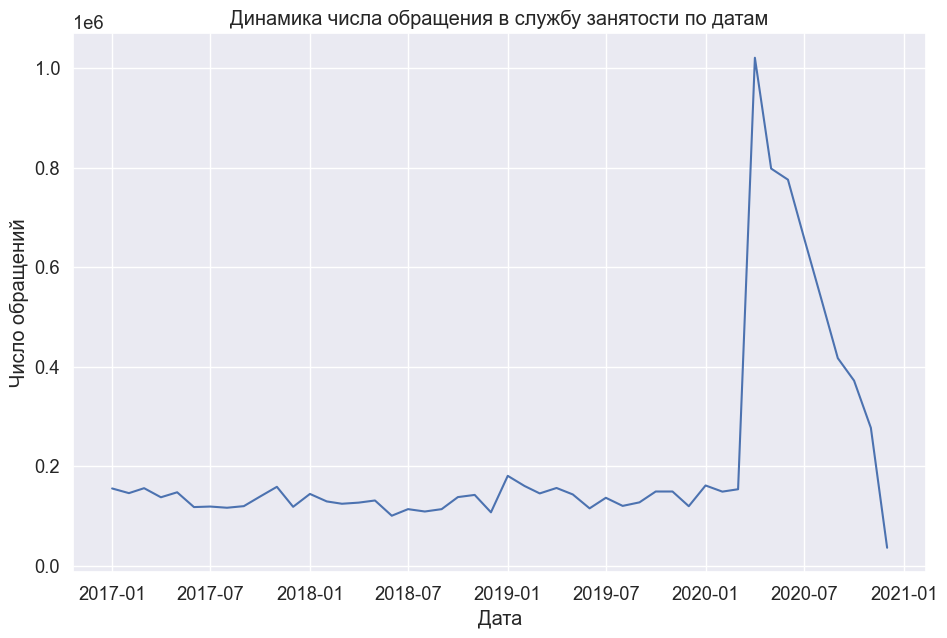

In [160]:
#визуализируем с помощью lineplot
sns.lineplot(data = count_date, x = 'month_application', y = 'count').set(title='Динамика числа обращения в службу занятости по датам',
                                                                 xlabel='Дата', 
                                                                 ylabel='Число обращений'
                                                                 )
plt.show()

На графике можно видеть резкое увеличение числа обращений в середине 2020 года. Вероятно данный рост связан с пандемией COVID-19, что привело к массовому сокращению сотрудников и прекращению деятельности предприятий. 

In [161]:
#составим сводную таблицу общего числа обращений в службу занятости по годам
count_year = df.pivot_table(index='year',
               values = 'count',
               aggfunc = 'sum').reset_index()
count_year

,year,count
0,2017,1636951
1,2018,1486266
2,2019,1708623
3,2020,5358366


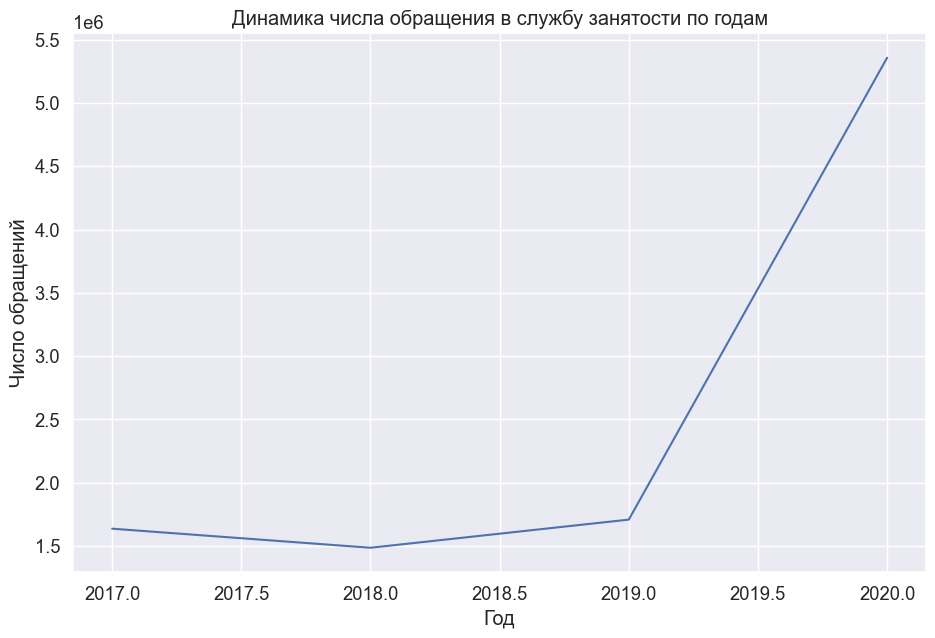

In [162]:
sns.lineplot(data = count_year, x = 'year', y = 'count').set(title='Динамика числа обращения в службу занятости по годам',
                                                                 xlabel='Год', 
                                                                 ylabel='Число обращений'
                                                                 )

plt.show()

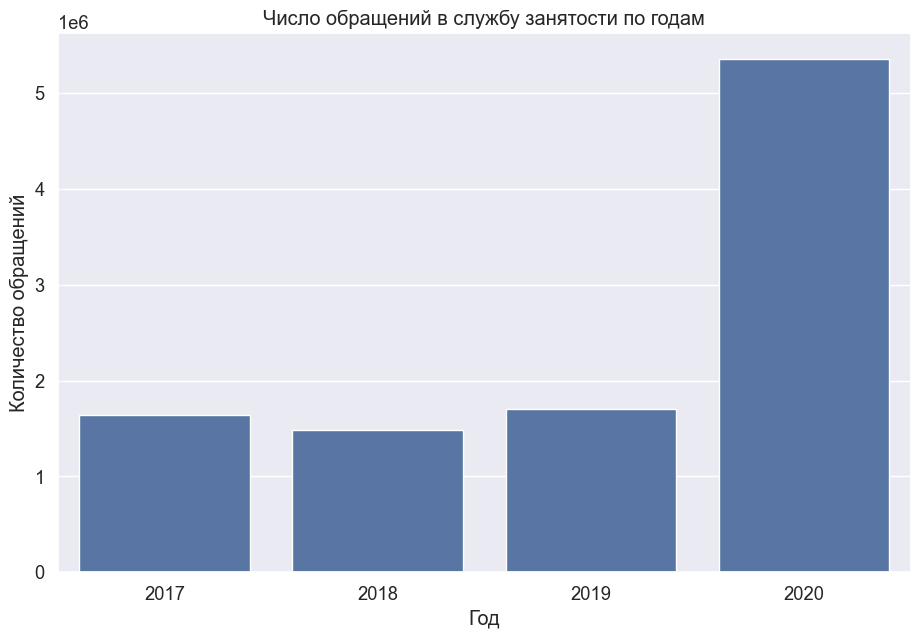

In [163]:
sns.barplot(data = count_year, x = 'year', y = 'count').set(title = 'Число обращений в службу занятости по годам', 
                                                            xlabel = 'Год', 
                                                            ylabel = 'Количество обращений')

plt.show()

В 2020 году количество обращений увеличилось более, чем в 3 раза и достигло уровня 5 358 371, в то время как в 2019 оно составляло 1 708 624.

In [164]:
#составим сводную таблицу повторных обращений в центр занятости
count_repeat = df.pivot_table(index = 'month_application',
                              values = ['count', 'hc_repeat'],
                              aggfunc = {'count':'sum', 'hc_repeat':'sum'}).reset_index()
count_repeat

,month_application,count,hc_repeat
0,2017-01-01,155746,49998
1,2017-02-01,146347,45870
2,2017-03-01,156272,48253
3,2017-04-01,138043,44019
4,2017-05-01,148049,47963
5,2017-06-01,118358,39521
6,2017-07-01,119418,38461
7,2017-08-01,117018,38312
8,2017-09-01,120229,38559
9,2017-10-01,139510,45285


[Text(0.5, 1.0, 'Динамика повторных обращений в службу занятости по годам'),
 Text(0.5, 0, 'Год'),
 Text(0, 0.5, 'Количество обращений')]

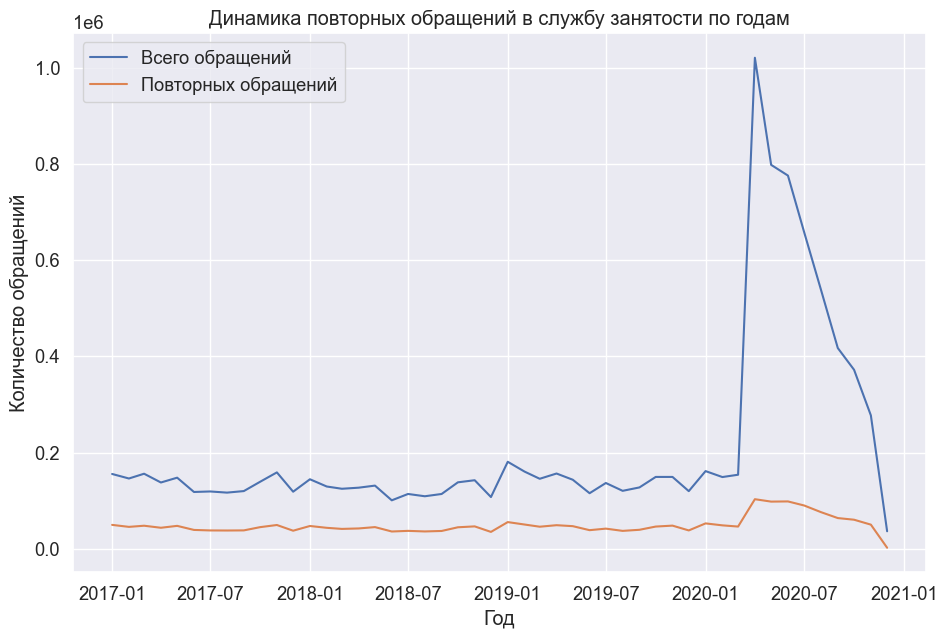

In [165]:
#визуализируем
sns.lineplot(data = count_repeat, x = 'month_application', y = 'count', label = 'Всего обращений')
(sns.lineplot(data = count_repeat, x = 'month_application', y = 'hc_repeat', label = 'Повторных обращений')
.set(title = 'Динамика повторных обращений в службу занятости по годам', xlabel = 'Год', ylabel = 'Количество обращений'))

Количество потворных обращений значительно меньше и в 2020 году имеет тенденцию к росту. Однако в 2020 году доля потворных обращений от общего числа сотавли всего лишь 14,8%, в то время как в 2017-2019 это значение превышает 30%.

### Вывод: <br>

Определив динамику числа обращений в слуюбу занятости и изучив информация в интернете, можно сделать вывод о том, что резкий скачок с 1 708 624 в 2019 году до 5 358 371 в 2020 году и рост повторных обращений связан с:
1) пандемией COVID-19
2) упрощение получения госуслуги - введение возможности дистанционной подачи завляения, снижение требования для её получения
3) увеличение размера пособия по безработице <br>

То есть в службу занятости могли обратиться слои населения, которые раньше не расчитывали на получение данной услуги или не испытывали трудностей с трудоустройством - экономически неактивное население и неформальный сектор. 

Резкое снижение к концу 2020 года связано с тем, что данные за декабрь неполные.


2. Определите число обращений в службу занятости по возрастным группам. Постройте столбчатую диаграмму.<br> Детализируйте по каждому году, визуализируйте результат.

In [166]:
#составим сводную таблицу числа обращений по возрастным группам
age_group = df.pivot_table(index = 'age',
                     values = 'count',
                     aggfunc = 'sum').reset_index()
age_group

,age,count
0,16-21,642895
1,22-27,1314197
2,28-33,2001622
3,34-39,1963617
4,40-45,1580491
5,46-51,1325802
6,52-57,1066379
7,58-60,295203


[Text(0.5, 1.0, 'Число обращений в службу занятости по возростным группам'),
 Text(0.5, 0, 'Возраст'),
 Text(0, 0.5, 'Количество обращений')]

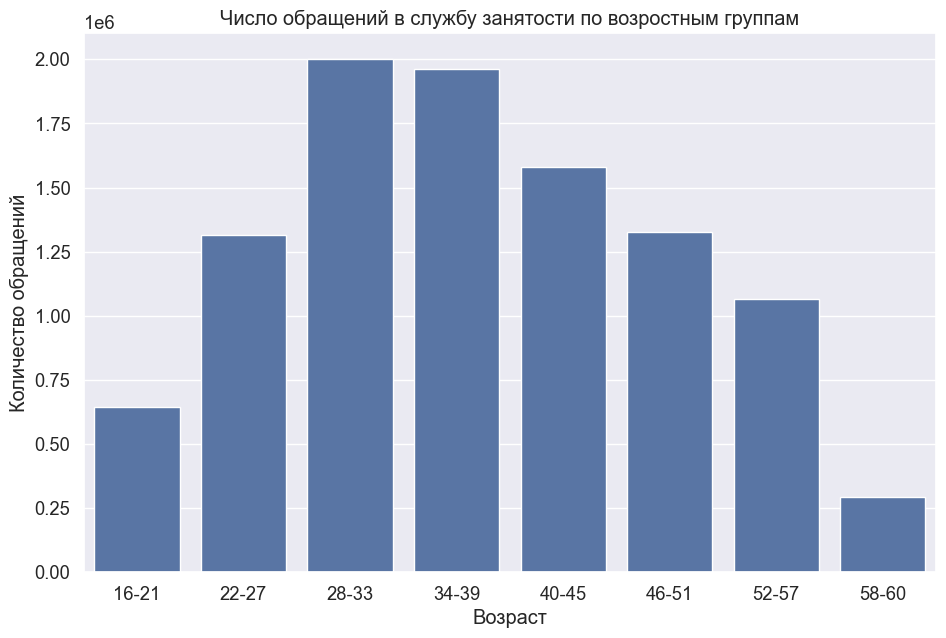

In [167]:
#визуализируем с помощью столбчатой диаграммы
sns.barplot(data = age_group, x = 'age', y = 'count').set(title = 'Число обращений в службу занятости по возростным группам', 
                                                          xlabel = 'Возраст', 
                                                          ylabel = 'Количество обращений')

Чаще всего в службу занятости обращаются люди в возрасте 28-33 лет, второе место у группы - 34-39 лет. Опираясь на пункт 1 можно предположить, что именно их сокращади в период пандемии. <br>

Люди в возрасте 58-60 не предъявляют спрос на работу - это происходит по нескольим причинам: сохранение рабочего места, нежелание обращаться в государственные службы, спрос на более молодых сотрудников и предпочтение отдыха. <br>

Молодежь 16-27 также обращается в службу занятости реже, можно обусловить это упором на получение высшего образование, трудоустройства через родителей, неофицальное трудоустройство, недоверие к государству.

In [168]:
#детализируем сводную таблицу по годам
age_group_year = df.pivot_table(index = ['age', 'year'],
                     values = 'count',
                     aggfunc = 'sum')
age_group_year

count
age   year         
16-21 2017   122823
      2018   101361
      2019   100517
      2020   318194
22-27 2017   202814
      2018   159944
      2019   170986
      2020   780453
28-33 2017   276401
      2018   245414
      2019   289323
      2020  1190484
34-39 2017   277531
      2018   261581
      2019   309486
      2020  1115019
40-45 2017   252922
      2018   242501
      2019   279276
      2020   805792
46-51 2017   235754
      2018   224407
      2019   255398
      2020   610243
52-57 2017   218311
      2018   199209
      2019   229192
      2020   419667
58-60 2017    50395
      2018    51849
      2019    74445
      2020   118514

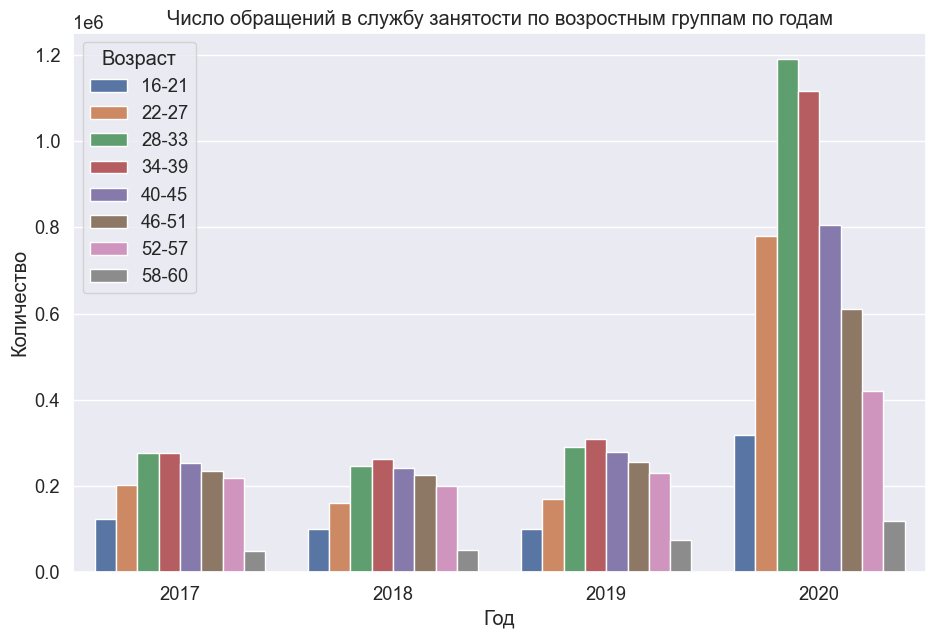

In [169]:
sns.barplot(data = age_group_year, x = 'year', y = 'count', hue = 'age').set(title = 'Число обращений в службу занятости по возростным группам по годам',
                                                                 xlabel = 'Год',
                                                                 ylabel = 'Количество')

plt.legend(title = 'Возраст')

### ВЫвод: <br>

Определив число обращений по возрастам можно сделать следующие выовды. <br>

Молодежь реже обращается в службу занятости, что может быть связано с продолжением образования, трудоустройства через родителей, неофицальное трудоустройство, подработки, недоверие к государству. <br>

Молодые люди в возрасте 22-39 лет предъявлюят высокий спрос на протяжении всего периода и наиболее уязвимы на рынке труда. Возможно это происходит из-за амбиций молодого поколения, недовольством оплаты турда и высоких требованиям к условиям рабочего места. Люди в возрасте 40-57 также испытывают сложности в поиске работы.
Опираясь на пункт 1 можно предположить, что именно эти категории подверглись сокращению, либо же работали неофициально. <br>

Показатель старшей возрастной группы несильно изменяется в течение четырех лет и придерживается низких знчаений даже. Это происходит из-за сохранения рабочего места, нежелание и невозможность обращения в государственные службы, спроса на более молодых сотрудников и предпочтение отдыха. <br>

На службу занятости оказывалась большая нагрузка в 2020 году, особенно со стороны молодых и средневозрастных граждан, требуется расширения программ поддержки и адаптации услуг к потребностям разных возрастных групп.



3. Определите общее число устроившихся на работу граждан, определите процент трудоустройства по всему датасету. Постройте столбчатую диаграмму.

In [170]:
#псотрроим сводную таблицу
find_job_data = df.pivot_table(index = 'find_new_job',
                values = 'count',
                aggfunc = {'sum', lambda x: (x.count()/len(df))*100}).round(1)
find_job_data.columns = ['per', 'count']
find_job_data

,per,count
find_new_job,,
False,57.3,6613539
True,42.7,3576667


[Text(0.5, 1.0, 'Число устроившихся на работу граждан'),
 Text(0.5, 0, 'Устройство на работу'),
 Text(0, 0.5, 'Количество')]

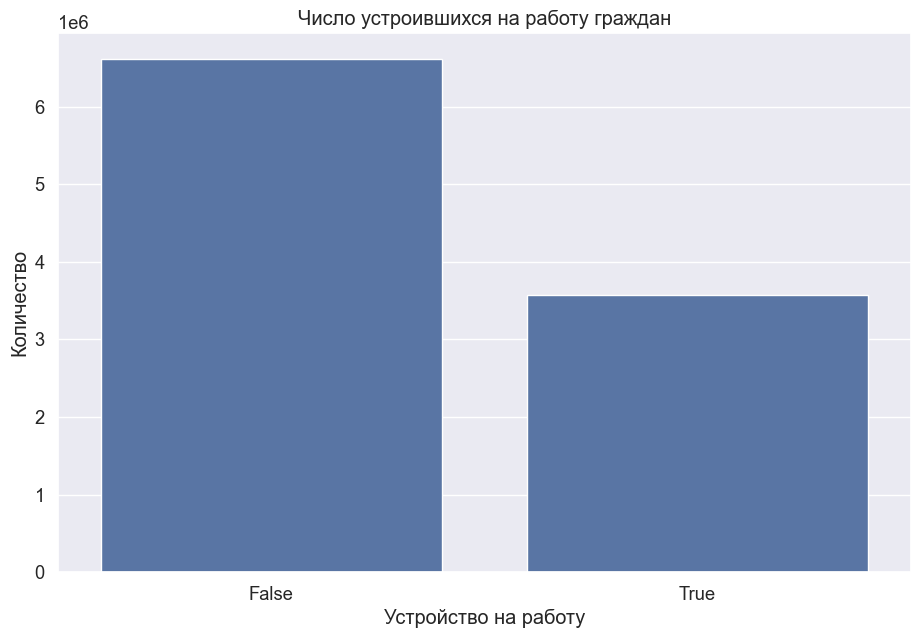

In [171]:
sns.barplot(data = find_job_data, x = 'find_new_job', y = 'count').set(title = 'Число устроившихся на работу граждан',
                                                            xlabel = 'Устройство на работу',
                                                            ylabel = 'Количество')

[Text(0.5, 1.0, 'Процент устроившихся на работу граждан'),
 Text(0.5, 0, 'Статус устройства на работу'),
 Text(0, 0.5, 'Процент, %')]

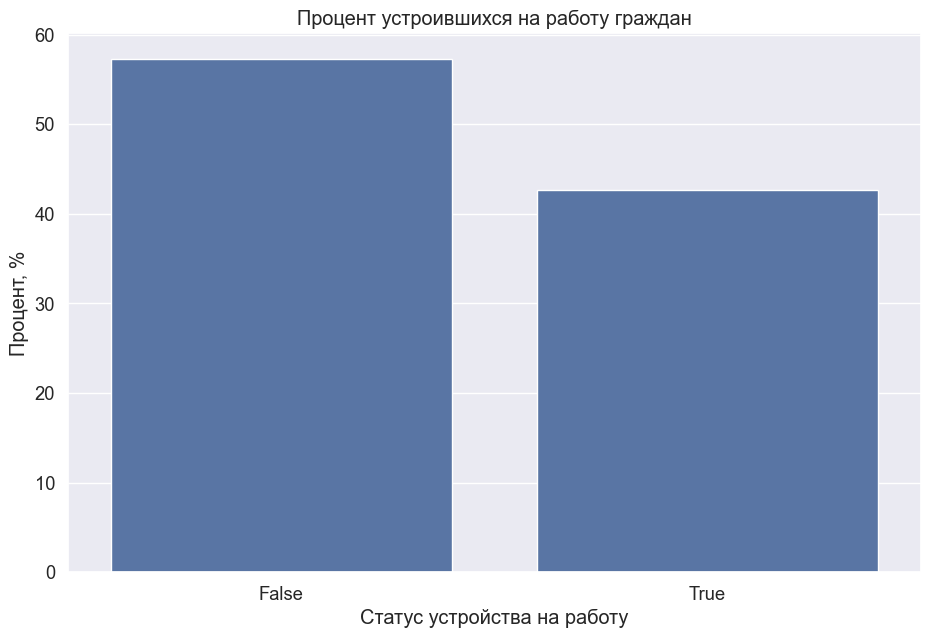

In [172]:
sns.barplot(data = find_job_data, x = 'find_new_job', y = 'per').set(title = 'Процент устроившихся на работу граждан',
                                                            xlabel = 'Статус устройства на работу',
                                                            ylabel = 'Процент, %')

### Вывод: 

После обращения в службу занятости число устроившихся на работу составило 3 576 669 (42,7%), однако это все равно меньше количества людей так и не получивших работу. То есть на рынке труда наблюдается диссбаланс. Интересно посмотреть на количество трудоустроенных по годам.

4. Определите соотношение трудоустройства по каждому году (в абсолютных значениях). Постройте столбчатую диаграмму.<br>
Выполните в относительных значениях, оцените динамику процента трудоустройства по годам.

In [174]:
#составим сводную таблицу соотношения трудоустройства по годам
find_job_year_data = df.pivot_table(index = ['year', 'find_new_job'],
                values = 'count',
                aggfunc = 'sum').reset_index()

find_job_year_data

,year,find_new_job,count
0,2017,False,761182
1,2017,True,875769
2,2018,False,696596
3,2018,True,789670
4,2019,False,894742
5,2019,True,813881
6,2020,False,4261019
7,2020,True,1097347


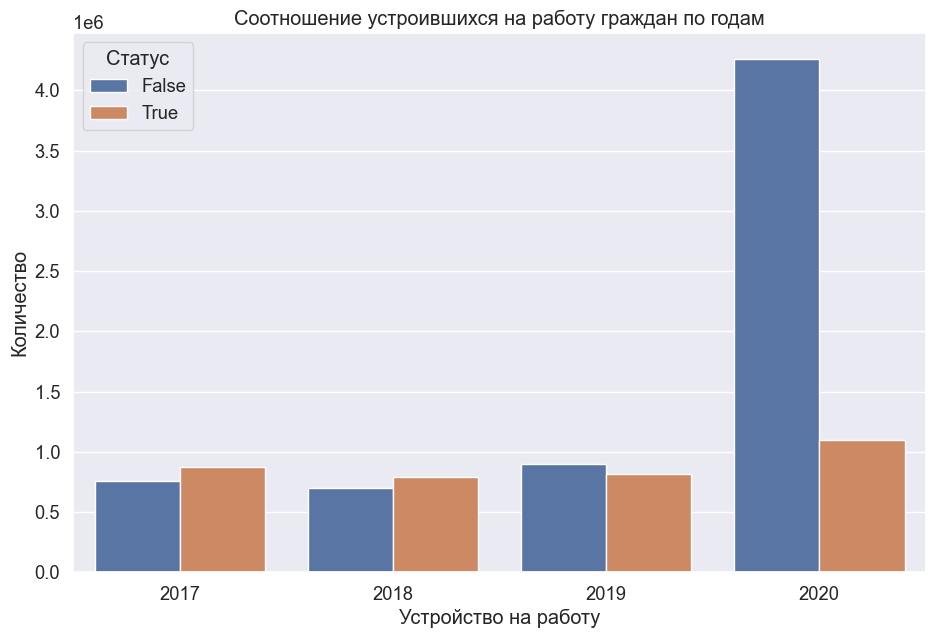

In [175]:
sns.barplot(data = find_job_year_data, x = 'year', y = 'count', hue = 'find_new_job').set(title = 'Соотношение устроившихся на работу граждан по годам', 
                                                                                          xlabel = 'Устройство на работу', 
                                                                                          ylabel = 'Количество')
plt.legend(title = 'Статус')
plt.show()

В 2020 намного сложнее было устроиться на работу, в то время как в предыдущие года количество безработных и нашедших работу граждан приблизительно равны.  Огромное количество граждан не получивших работу, может быть связано с преобладающей частью вновь зарегистрированного неактивного экономического населения или граждан, потерявших в результате пандемии.

In [176]:
total_year = df.groupby('year')['count'].sum().reset_index()
total_year.columns = ['year', 'total']
total_year

,year,total
0,2017,1636951
1,2018,1486266
2,2019,1708623
3,2020,5358366


In [177]:
find_job_year_data = find_job_year_data.merge(total_year, on = 'year')

In [178]:
#составим таблицу для относительных значений
find_job_year_data['per'] = ((find_job_year_data['count'] / find_job_year_data['total'])*100).round(2)
find_job_year_data

,year,find_new_job,count,total,per
0,2017,False,761182,1636951,46.50
1,2017,True,875769,1636951,53.50
2,2018,False,696596,1486266,46.87
3,2018,True,789670,1486266,53.13
4,2019,False,894742,1708623,52.37
5,2019,True,813881,1708623,47.63
6,2020,False,4261019,5358366,79.52
7,2020,True,1097347,5358366,20.48


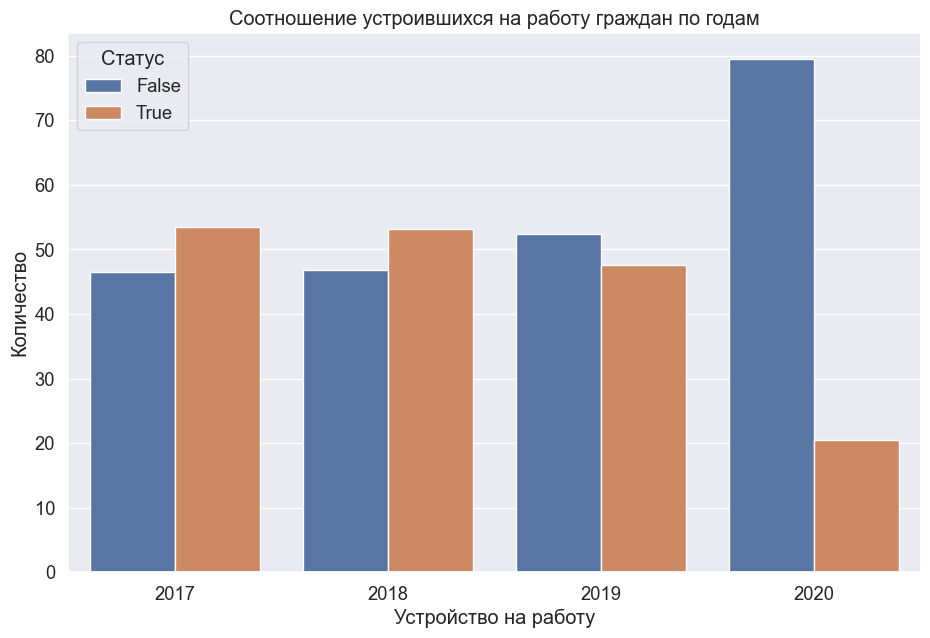

In [179]:
sns.barplot(data = find_job_year_data, x = 'year', y = 'per', hue = 'find_new_job').set(title = 'Соотношение устроившихся на работу граждан по годам', 
                                                                                          xlabel = 'Устройство на работу', 
                                                                                          ylabel = 'Количество')
plt.legend(title = 'Статус')
plt.show()

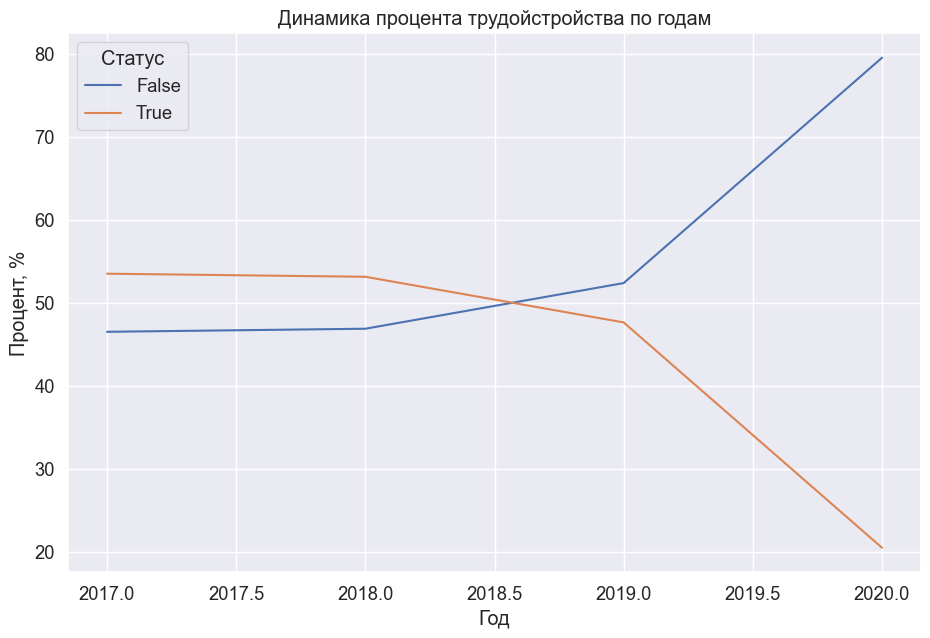

In [180]:
sns.lineplot(find_job_year_data, x = 'year', y = 'per', hue = 'find_new_job').set(title = 'Динамика процента трудойстройства по годам',
                                                                                  xlabel = 'Год',
                                                                                  ylabel = 'Процент, %')
plt.legend(title = 'Статус')
plt.show()

До 2019 года количество устроившихся на работу всегла превышало тех, кто раюоту не получил. Однако в 2019 ситуация резко меняется и к в 2020 году процент трудоустроившихся составляет всего лишь 20,5%.

### Вывод:
 
Определение соотношения числа трудоустроившихся по годам показало нам, что общее число граждан, не получивших работу - 6 613 545 и обусловлено преобладающим числом данного значения в 2020 году - 4 261 023(79,5%) к 1 097 348 (20,5%) трудоустроившихся. То есть можно выдвинуть предположение о связи данного явления с преобладающей частью вновь зарегистрированного экономически неактивного и неформально занятого населения, а также граждан, потерявших работу во вреям пандемии.

5. 
Осуществите категоризацию по столбцам <code>gender</code> и <code>education</code> в соответствии с исходными данными. Определите с каким образованием в службу занятости обращаются гражданине, ранее официально не работавшие. Определите соотношение трудоустройства по каждому уровню образования.

In [181]:
#составим таблицу с количеством граждан по полу и образованию
total_edu = df.groupby(['gender', 'education'])['count'].sum().reset_index()
#переименуем столбцы
total_edu.columns = ['gender', 'education', 'total']
total_edu

,gender,education,total
0,0.0,0.0,1223758
1,0.0,1.0,3178
2,0.0,2.0,718452
3,0.0,3.0,1082139
4,0.0,4.0,1355321
5,0.0,6.0,1032408
6,0.0,9.0,170094
7,1.0,0.0,914341
8,1.0,1.0,4688
9,1.0,2.0,712647


In [182]:
#составим сводную таблицу по полу и образованию, обращающихся в службу заности
education_didnotwork_data = df.pivot_table(index = ['gender', 'education'],
               columns = 'hc_didnotwork',
               values = 'count',
               aggfunc = 'sum')

education_didnotwork_data.columns = ['didnotwork', 'work']

education_didnotwork_data

didnotwork    work
gender education                    
0.0    0.0           1178522   45236
       1.0              2396     782
       2.0            503149  215303
       3.0            777393  304746
       4.0           1158402  196919
       6.0            941435   90973
       9.0            102250   67844
1.0    0.0            875459   38882
       1.0              3914     774
       2.0            540540  172107
       3.0            856334  235813
       4.0           1041354  159293
       6.0            474684   53944
       9.0             98785   52973

In [183]:
education_didnotwork_data = education_didnotwork_data.merge(total_edu, on = ['gender', 'education'])
education_didnotwork_data

,gender,education,didnotwork,work,total
0,0.0,0.0,1178522,45236,1223758
1,0.0,1.0,2396,782,3178
2,0.0,2.0,503149,215303,718452
3,0.0,3.0,777393,304746,1082139
4,0.0,4.0,1158402,196919,1355321
5,0.0,6.0,941435,90973,1032408
6,0.0,9.0,102250,67844,170094
7,1.0,0.0,875459,38882,914341
8,1.0,1.0,3914,774,4688
9,1.0,2.0,540540,172107,712647


In [184]:
education_didnotwork_data['per_didnotwork'] = ((education_didnotwork_data['didnotwork']/education_didnotwork_data['total'])*100).round(1)
education_didnotwork_data['per_work'] = ((education_didnotwork_data['work']/education_didnotwork_data['total'])*100).round(1)
education_didnotwork_data

,gender,education,didnotwork,work,total,per_didnotwork,per_work
0,0.0,0.0,1178522,45236,1223758,96.3,3.7
1,0.0,1.0,2396,782,3178,75.4,24.6
2,0.0,2.0,503149,215303,718452,70.0,30.0
3,0.0,3.0,777393,304746,1082139,71.8,28.2
4,0.0,4.0,1158402,196919,1355321,85.5,14.5
5,0.0,6.0,941435,90973,1032408,91.2,8.8
6,0.0,9.0,102250,67844,170094,60.1,39.9
7,1.0,0.0,875459,38882,914341,95.7,4.3
8,1.0,1.0,3914,774,4688,83.5,16.5
9,1.0,2.0,540540,172107,712647,75.8,24.2


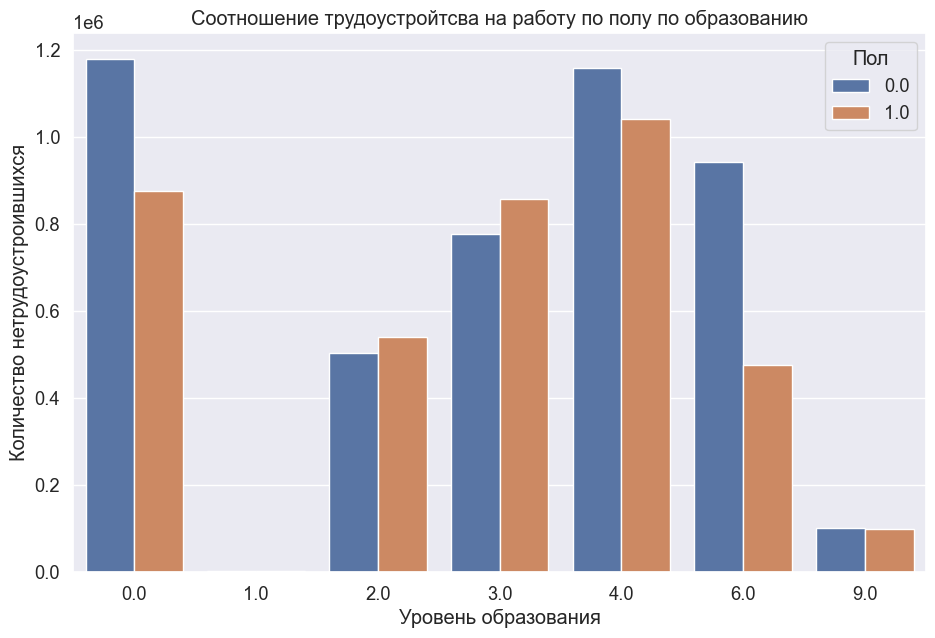

In [185]:
sns.barplot(data = education_didnotwork_data, x = 'education', y = 'didnotwork', hue = 'gender').set(title = 'Соотношение трудоустройтсва на работу по полу по образованию',
                                                                                                     xlabel = 'Уровень образования',
                                                                                                     ylabel = 'Количество нетрудоустроившихся')
plt.legend(title = 'Пол')
plt.show()

Таким образом чаще всего в центр занятости обращаются мужчины и женщины, имеющие среднее профессиональное образование. На втором месте - женщины с высшим образованием, на третьем - граждане со средним общем образованием. 
Сложности найти работу могут быть связаны с высокими требованиями момлодежи к условиям труда, нехватки опыта и квалификации. 
Количество граждан, имеющиих только начальное общее образование, обратившихся в уентр занятости крайне мало.

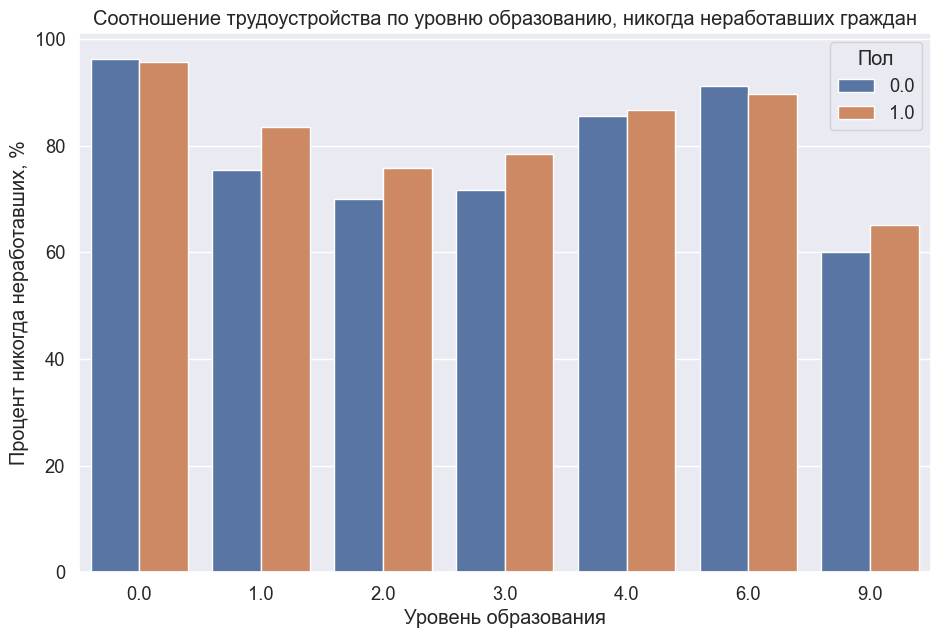

In [186]:
sns.barplot(data = education_didnotwork_data, x = 'education', y = 'per_didnotwork', hue = 'gender').set(title = 'Соотношение трудоустройства по уровню образованию, никогда неработавших граждан',
                                                                                                         xlabel = 'Уровень образования',
                                                                                                         ylabel = 'Процент никогда неработавших, %')
plt.legend(title = 'Пол')
plt.show()

Никогда не работавшие граждане испытвают трудности с трудоустройством. 
Наибольшее количество никогда не работавших имеют высшее образование, это может быть связано с тем, что студенты во время учебы не работают, а фокусируются на получении знаний. 

Мужчины чаще обращаются с начальным общим, основным общим и средним общим образованием еще ни разу не работав, уровень не сильно отличается. 

Граждане с другим образованием в большей стпени уже имеют опыт работы. Значительное количество граждан никогда не приступали к трудовой деятельности, что указывает на серьезные системные пробелы в интеграции населения на рынок труда


In [187]:
education_didnotwork_find_job_data = df.pivot_table(index =  ['gender', 'education'],
                                                    columns =['hc_didnotwork', 'find_new_job'],
                                                    values = 'count',
                                                    aggfunc = 'count')
education_didnotwork_find_job_data.columns = ['didnotwork_notfind', 'didnotwork_find', 'work_notfind', 'work_find']
education_didnotwork_find_job_data

didnotwork_notfind  didnotwork_find  work_notfind  work_find
gender education                                                              
0.0    0.0                     81366            74860          8319       3311
       1.0                      1550              516           627        114
       2.0                    161931           111011         69954      27090
       3.0                    208862           151577         63934      25152
       4.0                    314120           269917         70779      38341
       6.0                    190442           192855         31414      17137
       9.0                     29987            17276         16436       5629
1.0    0.0                     85420            74920          7879       3136
       1.0                      2157             1062           622        113
       2.0                    183778           140491         65776      26643
       3.0                    251552           195207         58286      23123
       4.0                    307271           262736         62377      34270
       6.0                    142577           123042         22659      10262
       9.0                     33741            22890         15402       5509

<Axes: xlabel='education', ylabel='didnotwork_find'>

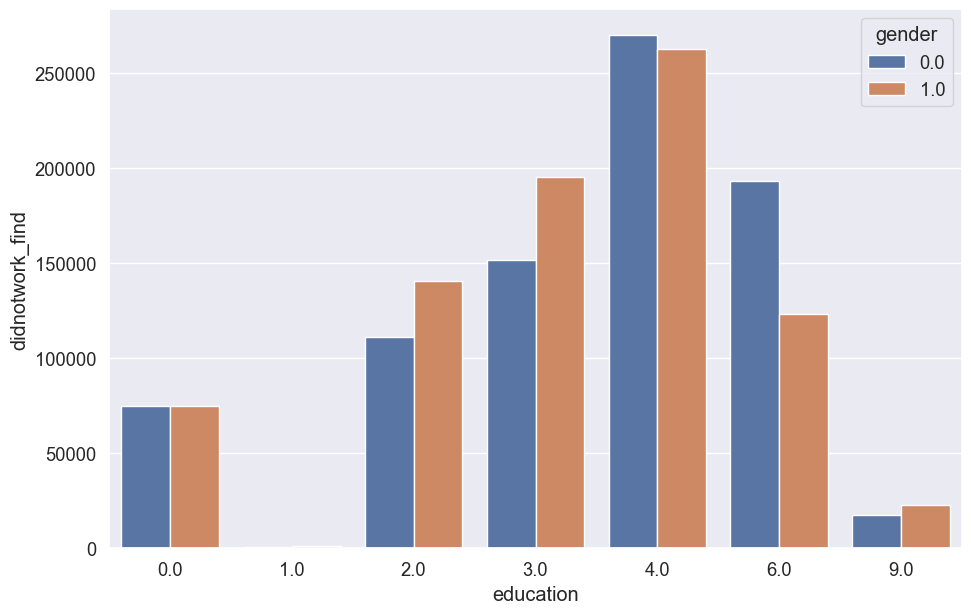

In [188]:
sns.barplot(education_didnotwork_find_job_data, x = 'education', y = 'didnotwork_find', hue = 'gender')

In [189]:
education_didnotwork_find_job_data = df.pivot_table(index =  ['gender', 'education'],
                                                    columns ='find_new_job',
                                                    values = 'count',
                                                    aggfunc = 'count')
education_didnotwork_find_job_data.columns = ['notfind', 'find']
education_didnotwork_find_job_data['total'] = education_didnotwork_find_job_data['notfind'] + education_didnotwork_find_job_data['find']
education_didnotwork_find_job_data['per_notfind'] = ((education_didnotwork_find_job_data['notfind']/education_didnotwork_find_job_data['total']) *100).round(1)
education_didnotwork_find_job_data['per_find'] = ((education_didnotwork_find_job_data['find']/education_didnotwork_find_job_data['total']) *100).round(1)

education_didnotwork_find_job_data

notfind    find   total  per_notfind  per_find
gender education                                                
0.0    0.0          89685   78171  167856         53.4      46.6
       1.0           2177     630    2807         77.6      22.4
       2.0         231885  138101  369986         62.7      37.3
       3.0         272796  176729  449525         60.7      39.3
       4.0         384899  308258  693157         55.5      44.5
       6.0         221856  209992  431848         51.4      48.6
       9.0          46423   22905   69328         67.0      33.0
1.0    0.0          93299   78056  171355         54.4      45.6
       1.0           2779    1175    3954         70.3      29.7
       2.0         249554  167134  416688         59.9      40.1
       3.0         309838  218330  528168         58.7      41.3
       4.0         369648  297006  666654         55.4      44.6
       6.0         165236  133304  298540         55.3      44.7
       9.0          49143   28399   77542         63.4      36.6

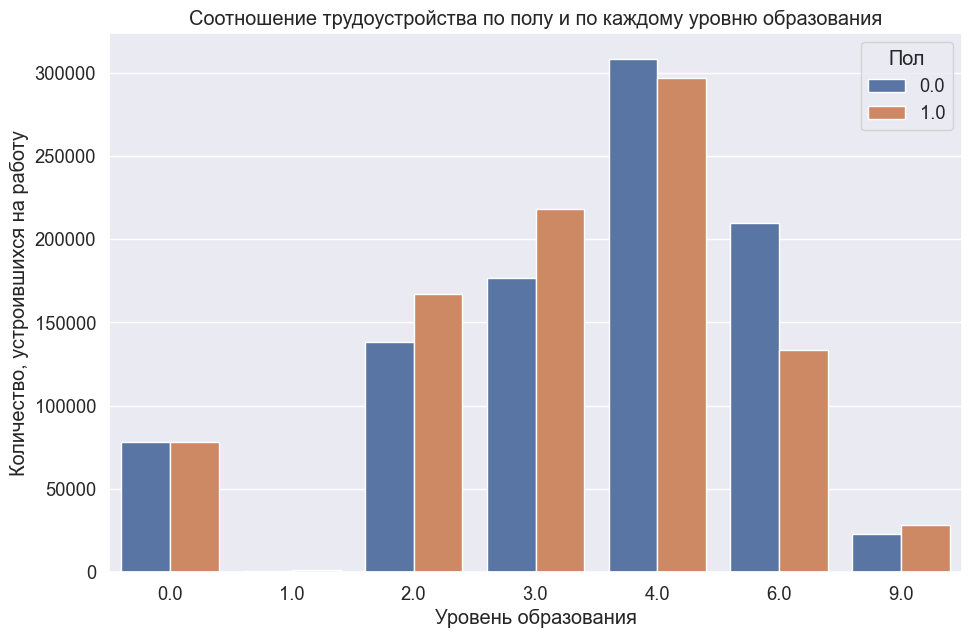

In [190]:
sns.barplot(education_didnotwork_find_job_data, x = 'education', y = 'find', hue = 'gender').set(title = 'Cоотношение трудоустройства по полу и по каждому уровню образования',
                                                                                                 xlabel = 'Уровень образования',
                                                                                                 ylabel = 'Количество, устроившихся на работу')
plt.legend(title = 'Пол')
plt.show()

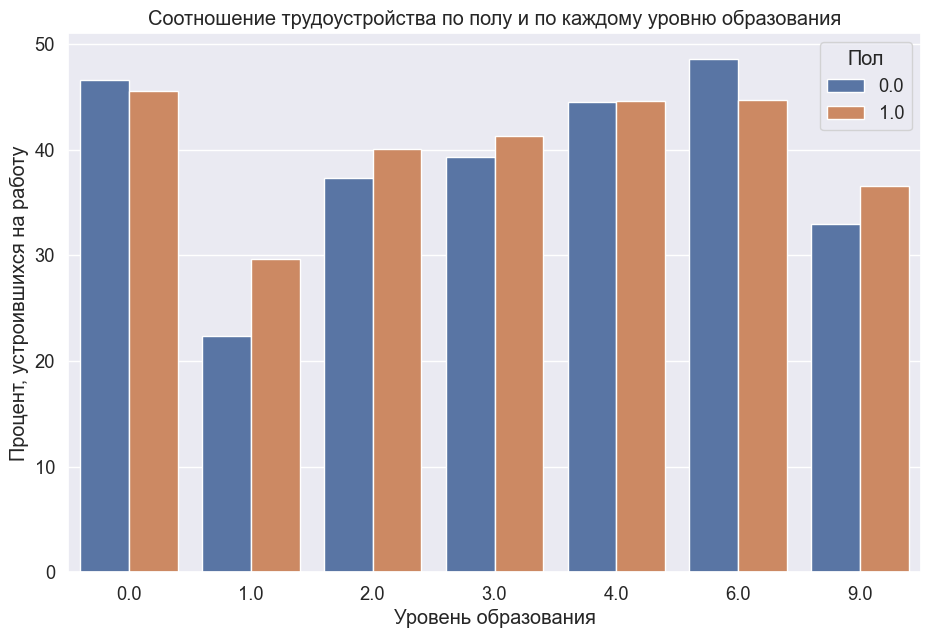

In [191]:
sns.barplot(education_didnotwork_find_job_data, x = 'education', y = 'per_find', hue = 'gender').set(title = 'Cоотношение трудоустройства по полу и по каждому уровню образования',
                                                                                                 xlabel = 'Уровень образования',
                                                                                                 ylabel = 'Процент, устроившихся на работу')
plt.legend(title = 'Пол')
plt.show()

Нет значительно различия в устройстве на работу для женщин и мужчин.


6. Исследуйте безработицу в России отдельно за 2000 год (за исключением декабря 2020!). Создайте срез данных.<br>

6.1 Определите динамику числа безработных и нашедших работу за 2020 год по месяцам.<br>

In [192]:
df.query('year == 2020').pivot_table(index = 'find_new_job',
                                     values = 'count',
                                     aggfunc = 'sum')

,count
find_new_job,
False,4261019
True,1097347


In [193]:
month_find_job_data = df.query('year == 2020').pivot_table(index = ['month','find_new_job'],
                                     values = 'count',
                                     aggfunc = 'sum')
month_find_job_data

count
month find_new_job        
1     False          98098
      True           63615
2     False          96326
      True           53040
3     False         104349
      True           49817
4     False         720765
      True          299564
5     False         577112
      True          220721
6     False         622049
      True          153530
7     False         545431
      True          112190
8     False         465066
      True           73088
9     False         374197
      True           43106
10    False         349700
      True           22460
11    False         271423
      True            6008
12    False          36503
      True             208

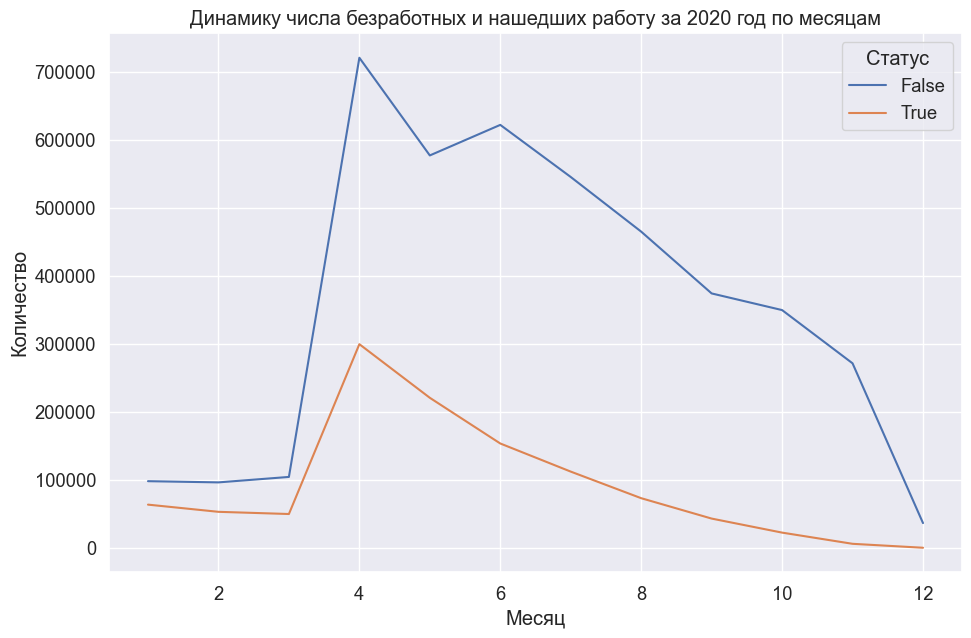

In [194]:
sns.lineplot(data = month_find_job_data, x = 'month', y = 'count', hue = 'find_new_job').set(title = 'Динамику числа безработных и нашедших работу за 2020 год по месяцам',
                                                                       xlabel = 'Месяц',
                                                                       ylabel = 'Количество')
plt.legend(title = 'Статус')
plt.show()

 
На графике отчетливо видно, что в апреле месяц наибольшее количество обратившихся, что объясняет максимальное количество не трудостроенных. Как мы поянли из исследования выше, такой рост (~80%) обуславливается поддержкой правительства россиян, потерявших работу из-за пандемического кризиса, правительствос помощью увеличения максимальный размер пособия по безработице. Для сравнения: в марте 2020 года в центрах занятости были зарегистрированы 154 166. 

До вмешательства правительства количество граждан, получивших работу незначительно отличалось от безработных, однако в последствии их число уменьшилось в 4 раза относительно безработных. То есть увеличился уровень регистрируемой безработицы, так как сложности 
После июня 2020 года число обратившихся постепенно уменьшается. Так как данные неполные мы не можем сделать вывод о том, какой цифры достигла безработица на конец года.

6.2 Определите процент трудоустройства по гендерной принадлежности<br>

In [195]:
#найдем общее число мужчин и женщин, обратившихся в 2020 году
gender_total = df.query('year == 2020').groupby(['gender'])['count'].sum().reset_index()
gender_total.columns = ['gender', 'total']
gender_total

,gender,total
0,0.0,3071983
1,1.0,2286383


In [196]:
#составим сводную таблицу по безработным и устроившимся на работу
gender_find_job_data = df.query('year == 2020').pivot_table(index = ['find_new_job', 'gender'],
                                     values = 'count',
                                     aggfunc = 'sum').reset_index()
gender_find_job_data

,find_new_job,gender,count
0,False,0.0,2467348
1,False,1.0,1793671
2,True,0.0,604635
3,True,1.0,492712


In [197]:
gender_find_job_data = gender_find_job_data.merge(gender_total, on = 'gender')
gender_find_job_data

,find_new_job,gender,count,total
0,False,0.0,2467348,3071983
1,False,1.0,1793671,2286383
2,True,0.0,604635,3071983
3,True,1.0,492712,2286383


In [198]:
#добавим доли
gender_find_job_data['per'] = ((gender_find_job_data['count']/gender_find_job_data['total'])*100).round(2)
gender_find_job_data

,find_new_job,gender,count,total,per
0,False,0.0,2467348,3071983,80.32
1,False,1.0,1793671,2286383,78.45
2,True,0.0,604635,3071983,19.68
3,True,1.0,492712,2286383,21.55


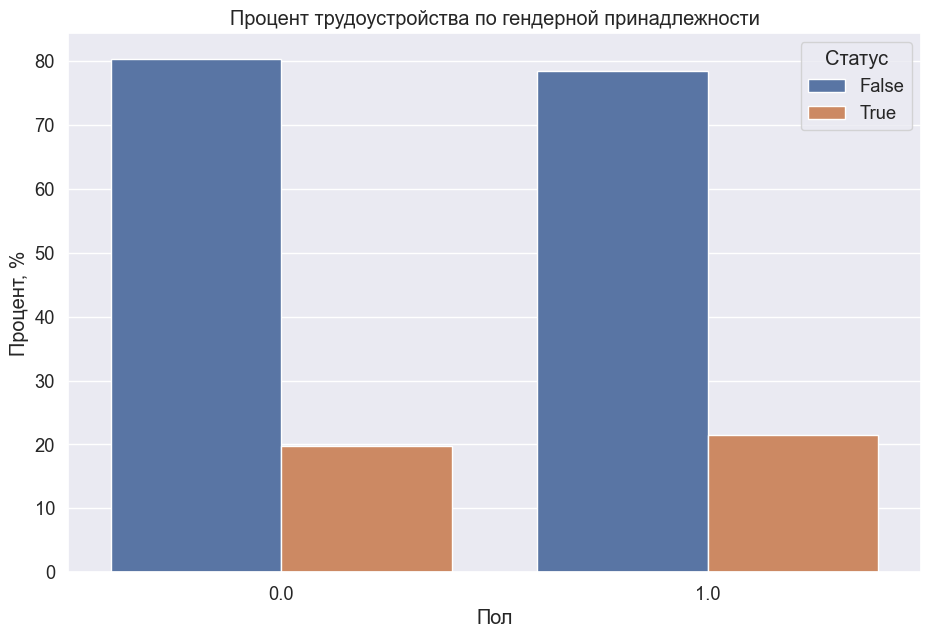

In [199]:
sns.barplot(gender_find_job_data, x = 'gender', y = 'per', hue = 'find_new_job').set(title = 'Процент трудоустройства по гендерной принадлежности',
                                                                                           xlabel = 'Пол',
                                                                                           ylabel = 'Процент, %')
plt.legend(title = 'Статус')
plt.show()

Нет диссбаланса и различий в трудоустройстве по гендерному признаку.

6.3 Определите число обращений в службу занятости по федеральным округам.<br>

In [23]:
district_data = df.query('year == 2020').pivot_table(index = 'district',
                                     values = 'count',
                                     aggfunc = 'sum').reset_index()
district_data

,district,count
0,Дальневосточный федеральный округ,289616
1,Приволжский федеральный округ,1054517
2,Северо-Западный федеральный округ,478114
3,Северо-Кавказский федеральный округ,702977
4,Сибирский федеральный округ,721710
5,Уральский федеральный округ,461281
6,Центральный федеральный округ,1039433
7,Южный федеральный округ,610718


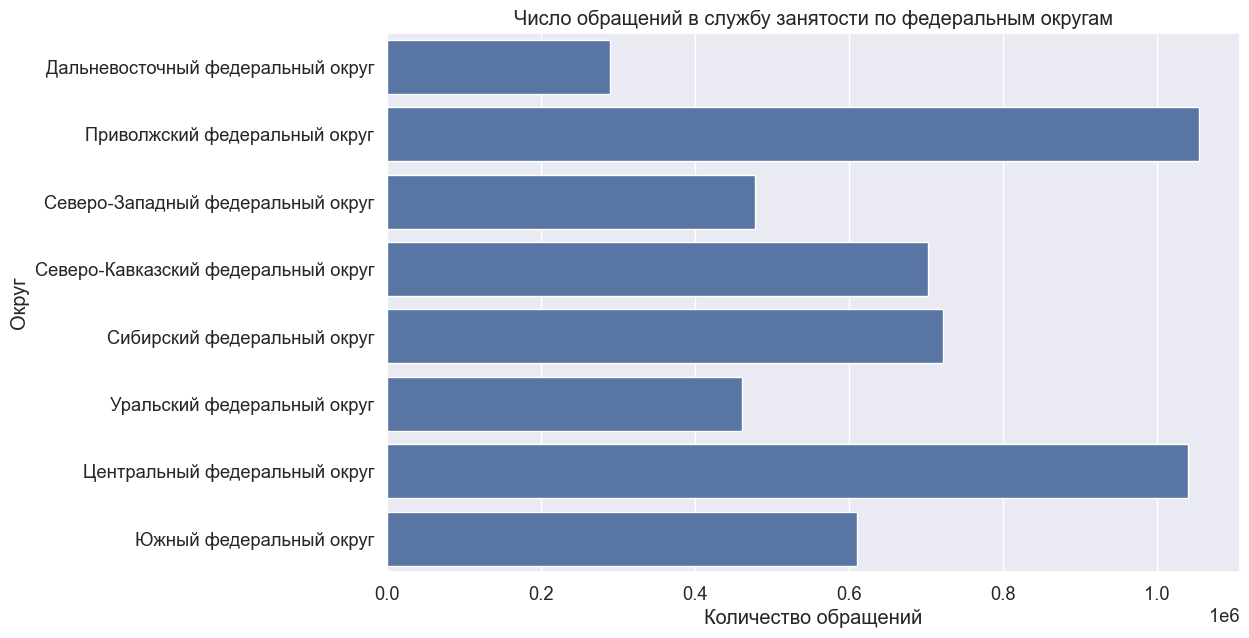

In [24]:
sns.barplot(district_data, x = 'count', y = 'district').set(title = 'Число обращений в службу занятости по федеральным округам',
                                                            xlabel = 'Количество обращений',
                                                            ylabel = 'Округ')
plt.show()

Наибольшее количество обращений наблюдается в Центральном и Приволжском федеральных округах (1039433 и 1054517), что связано с высоким уровнем насления, а также с специализацией данных регионов - пандемия обострила структруные проблемы в экономике данных регионов. В Приволжском округе основной специализацией является нефтедобывающая промышленность - сокращение производства и услуг вызвало массовые увольнения, остра проблема нехватки квалифицированных кадров. В центральном округе развита свера услуг - многие центры, где активно общаются с клиентами, также закрылись на время локдауна.

6.4 Определите разброс числа объявлений по регионам с помощью boxplot.<br>

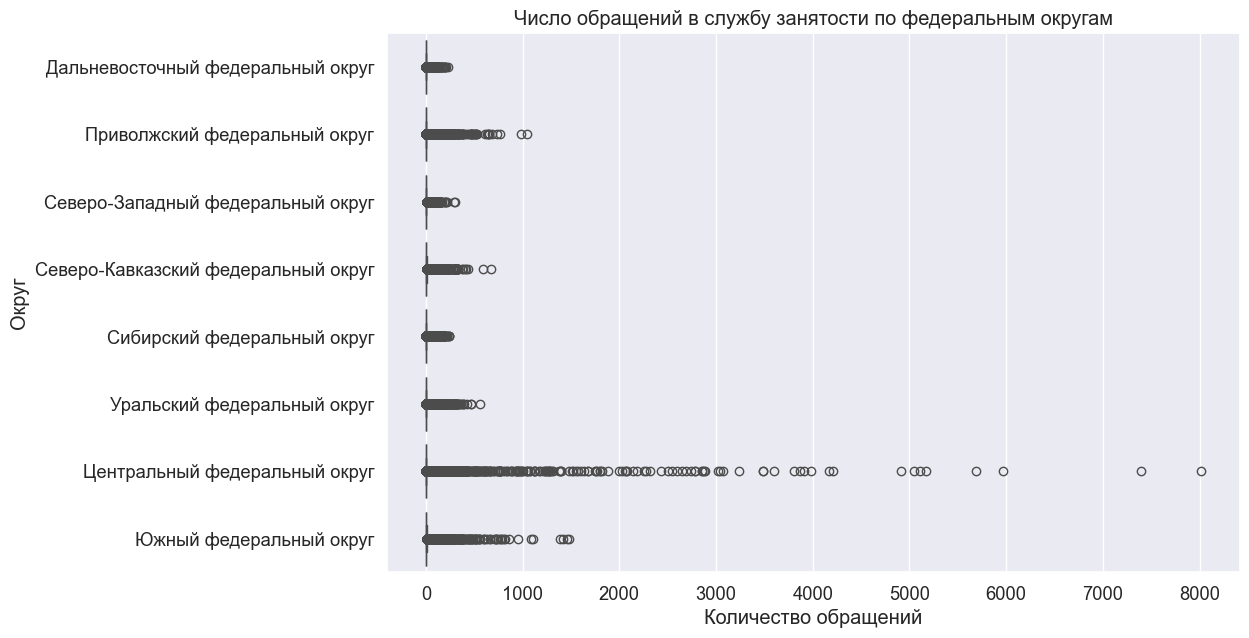

In [36]:
sns.boxplot(df.query('year == 2020'), x = 'count', y = 'district').set( title = 'Число обращений в службу занятости по федеральным округам',
                                                            xlabel = 'Количество обращений',
                                                            ylabel = 'Округ')

plt.show()

In [ ]:
Можно увидеть большое количество выбросов среди количества обращений, укрупним

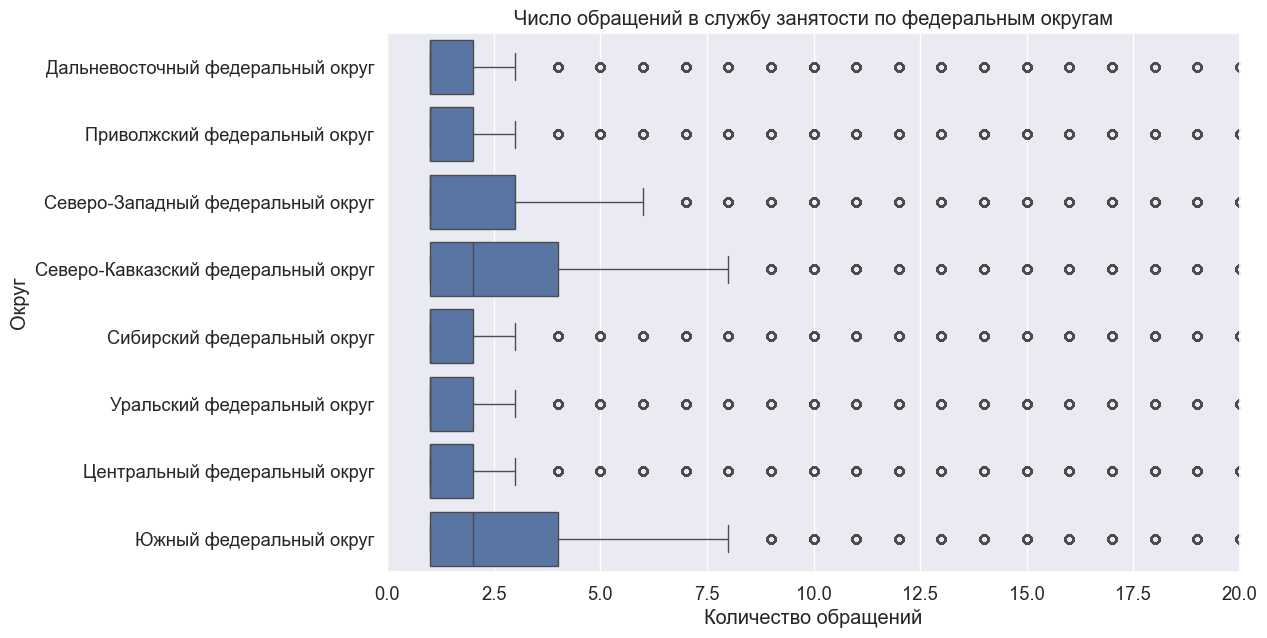

In [38]:
sns.boxplot(df.query('year == 2020'), x = 'count', y = 'district').set(xlim = (0,20), title = 'Число обращений в службу занятости по федеральным округам',
                                                            xlabel = 'Количество обращений',
                                                            ylabel = 'Округ')

plt.show()

Отсувтие нижних усов говрит о том что минимальное значение также является первым квантилем, то есть 1. В нескольких регионах боксплоты совпдают. Максимальные значения обращений по признакам наблюдаются в Северо-Кавказском и Южном федеральных округах, что может быть связано с демографической ситуацией, уровнем образования в данных регионах и уже имеющейся высокой структурной безработицей.

6.5 Определите число обращений в службу занятости в Северо-Западном федеральном округе по регионам.<br>

In [203]:
#составим сводную таблицу числа обращений в службу занятости в Северо-Западном федеральном округе по регионам
#с помощью метода query 
district_region_data = df.query('year == 2020 and district == "Северо-Западный федеральный округ"').pivot_table(index = 'region',
                                                                                                                values = 'count',
                                                                                                                aggfunc = 'sum')
district_region_data

,count
region,
Архангельская область,42057
Вологодская область,50357
Калининградская область,52507
Ленинградская область,49708
Мурманская область,23191
Ненецкий автономный округ,1889
Новгородская область,20112
Псковская область,17542
Республика Карелия,27755


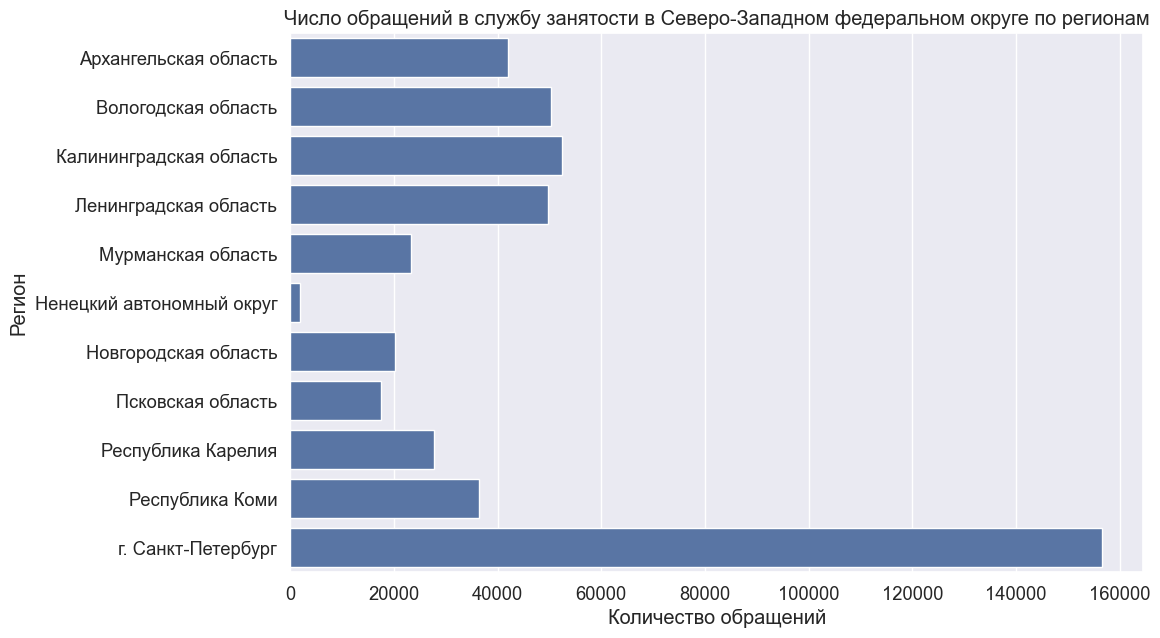

In [204]:
sns.barplot(district_region_data, x = 'count', y = 'region').set(title = 'Число обращений в службу занятости в Северо-Западном федеральном округе по регионам',
                                                                 xlabel = 'Количество обращений',
                                                                 ylabel = 'Регион')
plt.show()

Наибольшее количество обращений в Санкт-Петербурге (156 668) - связано с количеством населения (5,4 млн. человек на 2020 год), наименьшее количество обращений  в Ненецком (1889), в нем проживало 42 854 человека.

6.6 Определите процент трудоустройства по федеральным округам.<br>

In [207]:
#сводная таблица процента трудоустройства по регионам
district_per_data = df.query('year == 2020').pivot_table(index = ['district', 'find_new_job'],
                                     values = 'count',
                                     aggfunc = {'sum', lambda x: (x.sum()*100/df.query('year == 2020')['count'].sum()).round(2)}).reset_index()
district_per_data.columns = ['district', 'find_new_job', 'per', 'count']
district_per_data

,district,find_new_job,per,count
0,Дальневосточный федеральный округ,False,4.39,235396
1,Дальневосточный федеральный округ,True,1.01,54220
2,Приволжский федеральный округ,False,14.98,802752
3,Приволжский федеральный округ,True,4.70,251765
4,Северо-Западный федеральный округ,False,6.96,372834
5,Северо-Западный федеральный округ,True,1.96,105280
6,Северо-Кавказский федеральный округ,False,12.37,662618
7,Северо-Кавказский федеральный округ,True,0.75,40359
8,Сибирский федеральный округ,False,10.07,539622
9,Сибирский федеральный округ,True,3.40,182088


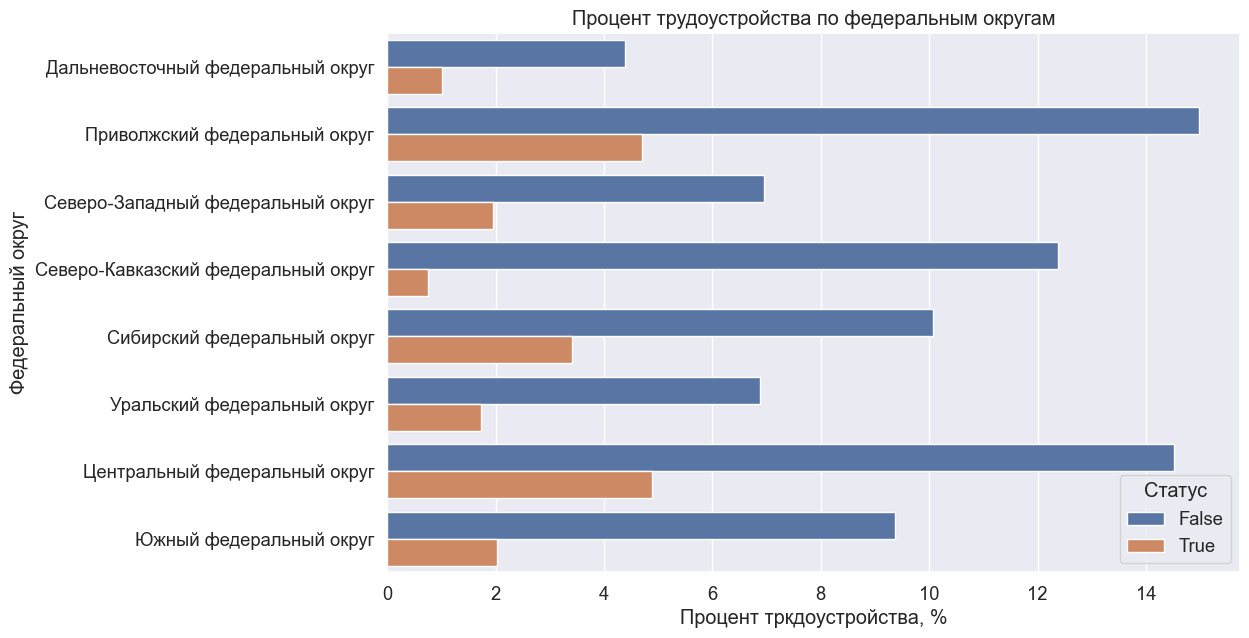

In [208]:
sns.barplot(district_per_data, x = 'per', y = 'district', hue = 'find_new_job').set(title = 'Процент трудоустройства по федеральным округам',
                                                              xlabel = 'Процент тркдоустройства, %',
                                                              ylabel = 'Федеральный округ')
plt.legend(title = 'Статус')
plt.show()

В лидерах - Приволжский и Центральный федеральный округ - их значения практически не отличаются. Низкий спрос на труд  в 2020 году не позволял подавляющему большинству граждан найти работу. Наибольшие сложности испытывали жители Северо-Кавказского региона, что объясняется струтутрынми проблемами: отсутствие крупных предприятий, низкая зарплата и высокий рост населения в горных районах Дагестана, для которого недостаточно рабочих мест.

6.7 Определите процент трудоустройства по регионам для каждого федерального округа. Реализуйте в цикле<br>

                          region  find_new_job    sum    per
0               Амурская область         False  23624   8.16
1               Амурская область          True   7345   2.54
2   Еврейская автономная область         False   5037   1.74
3   Еврейская автономная область          True   1500   0.52
4             Забайкальский край         False  44299  15.30
5             Забайкальский край          True   9103   3.14
6                Камчатский край         False   5176   1.79
7                Камчатский край          True   1840   0.64
8            Магаданская область         False   2843   0.98
9            Магаданская область          True    711   0.25
10               Приморский край         False  46425  16.03
11               Приморский край          True   8968   3.10
12            Республика Бурятия         False  33602  11.60
13            Республика Бурятия          True   7037   2.43
14      Республика Саха (Якутия)         False  40028  13.82
15      Республика Саха 

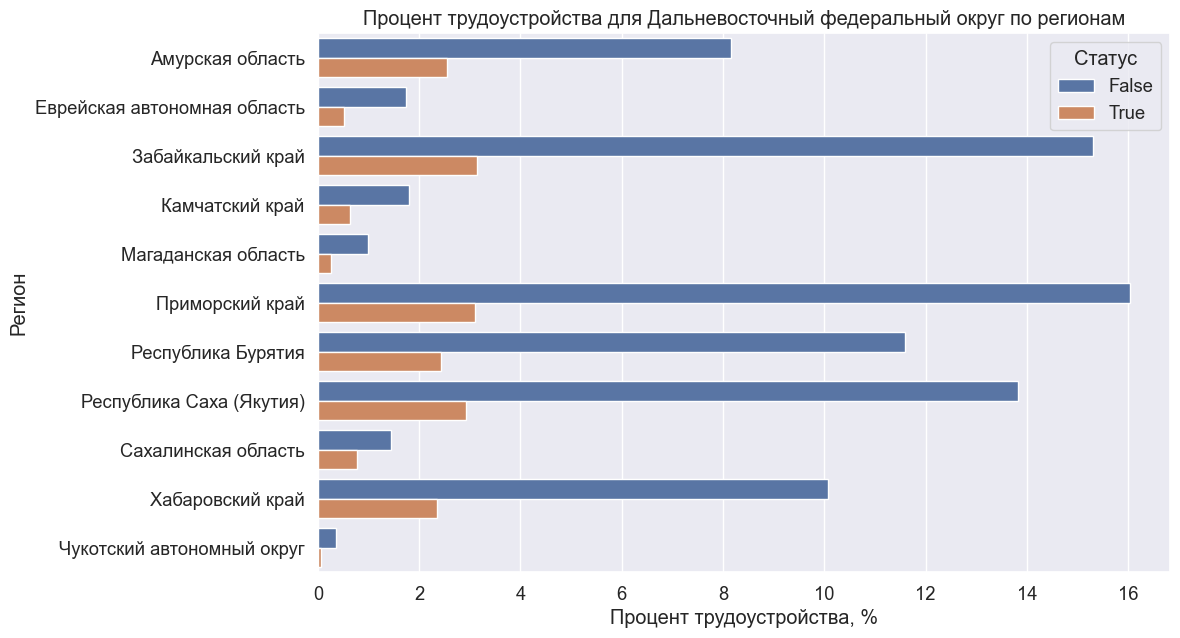

                              region  find_new_job     sum    per
0                  Кировская область         False   33179   3.15
1                  Кировская область          True   13086   1.24
2              Нижегородская область         False   71189   6.75
3              Нижегородская область          True   20690   1.96
4               Оренбургская область         False   79844   7.57
5               Оренбургская область          True   17671   1.68
6                 Пензенская область         False   26908   2.55
7                 Пензенская область          True   21356   2.03
8                      Пермский край         False   72107   6.84
9                      Пермский край          True   24879   2.36
10           Республика Башкортостан         False  148103  14.04
11           Республика Башкортостан          True   37589   3.56
12               Республика Марий Эл         False   13671   1.30
13               Республика Марий Эл          True    4144   0.39
14        

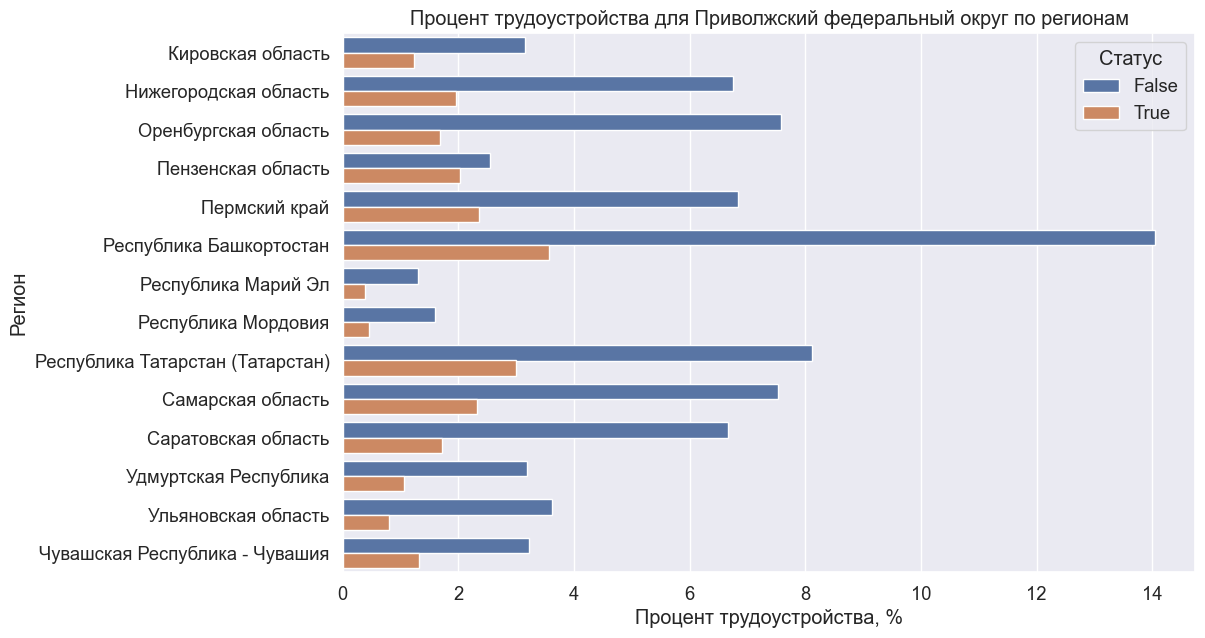

                       region  find_new_job     sum    per
0       Архангельская область         False   32905   6.88
1       Архангельская область          True    9152   1.91
2         Вологодская область         False   37497   7.84
3         Вологодская область          True   12860   2.69
4     Калининградская область         False   43787   9.16
5     Калининградская область          True    8720   1.82
6       Ленинградская область         False   38982   8.15
7       Ленинградская область          True   10726   2.24
8          Мурманская область         False   16749   3.50
9          Мурманская область          True    6442   1.35
10  Ненецкий автономный округ         False    1539   0.32
11  Ненецкий автономный округ          True     350   0.07
12       Новгородская область         False   15692   3.28
13       Новгородская область          True    4420   0.92
14          Псковская область         False   13820   2.89
15          Псковская область          True    3722   0.

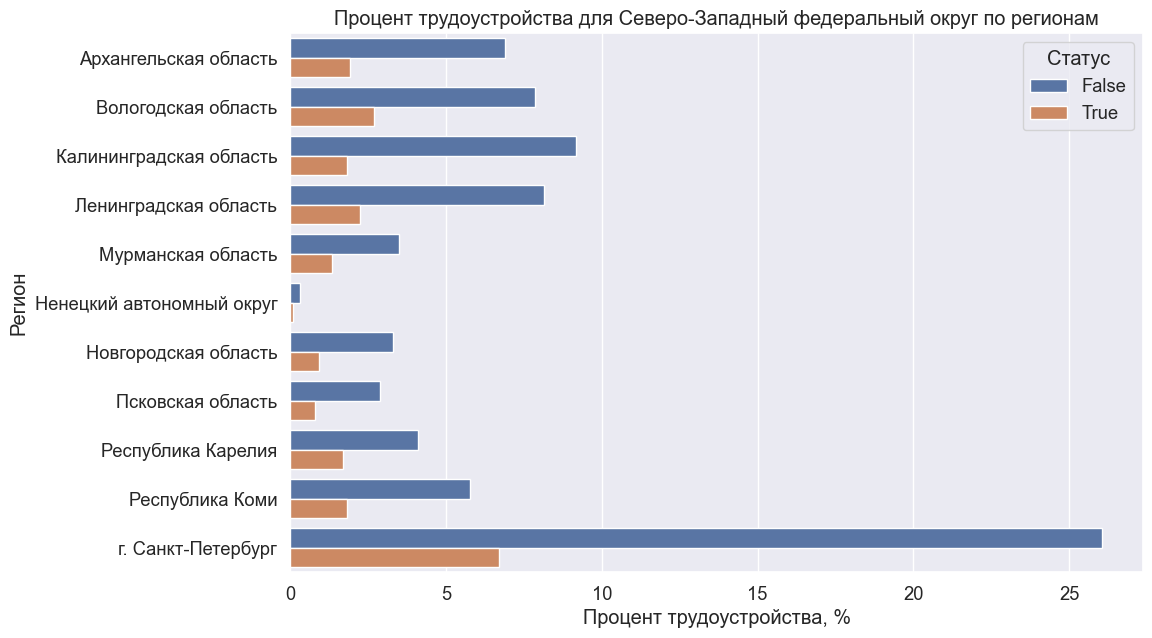

                                 region  find_new_job     sum    per
0       Кабардино-Балкарская Республика         False   76783  10.92
1       Кабардино-Балкарская Республика          True    2186   0.31
2       Карачаево-Черкесская Республика         False   28648   4.08
3       Карачаево-Черкесская Республика          True    2107   0.30
4                   Республика Дагестан         False  161752  23.01
5                   Республика Дагестан          True    9340   1.33
6                  Республика Ингушетия         False   61278   8.72
7                  Республика Ингушетия          True      51   0.01
8   Республика Северная Осетия - Алания         False   31490   4.48
9   Республика Северная Осетия - Алания          True    1128   0.16
10                  Ставропольский край         False   89586  12.74
11                  Ставропольский край          True   14355   2.04
12                 Чеченская Республика         False  213081  30.31
13                 Чеченская Респу

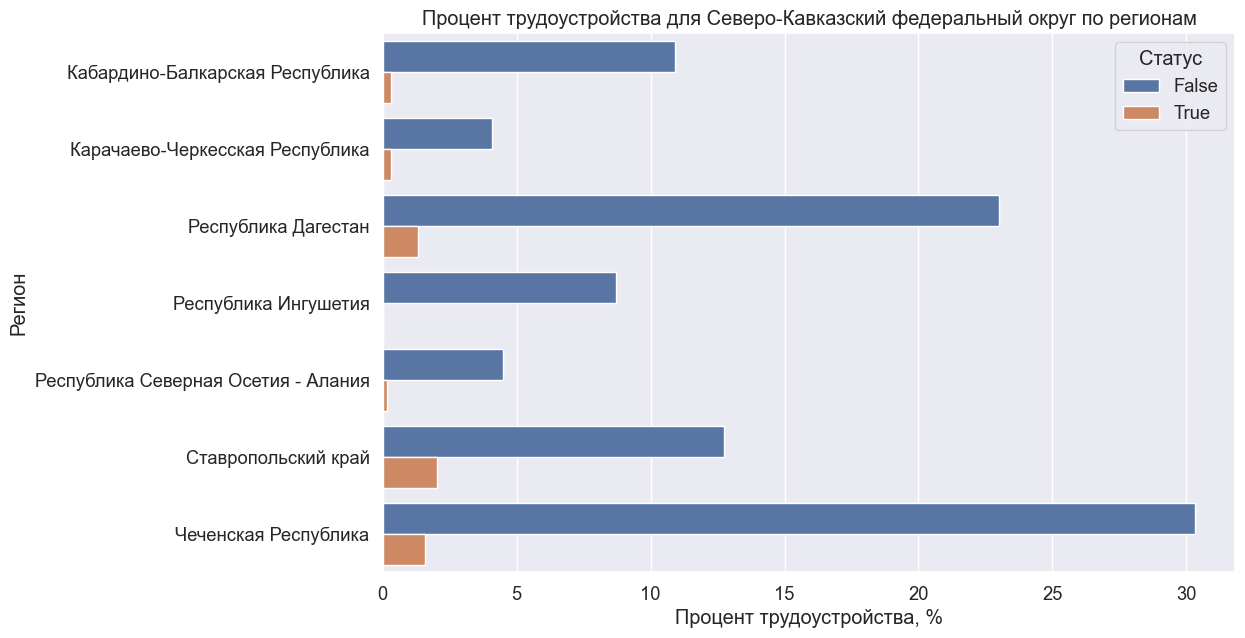

                   region  find_new_job    sum    per
0          Алтайский край         False  48150   6.67
1          Алтайский край          True  15619   2.16
2       Иркутская область         False  67456   9.35
3       Иркутская область          True  27858   3.86
4     Кемеровская область         False  95124  13.18
5     Кемеровская область          True  27883   3.86
6       Красноярский край         False  79759  11.05
7       Красноярский край          True  32680   4.53
8   Новосибирская область         False  81669  11.32
9   Новосибирская область          True  38096   5.28
10         Омская область         False  67675   9.38
11         Омская область          True  19612   2.72
12       Республика Алтай         False  15463   2.14
13       Республика Алтай          True   2886   0.40
14        Республика Тыва         False  31237   4.33
15        Республика Тыва          True   4052   0.56
16     Республика Хакасия         False  15798   2.19
17     Республика Хакасия   

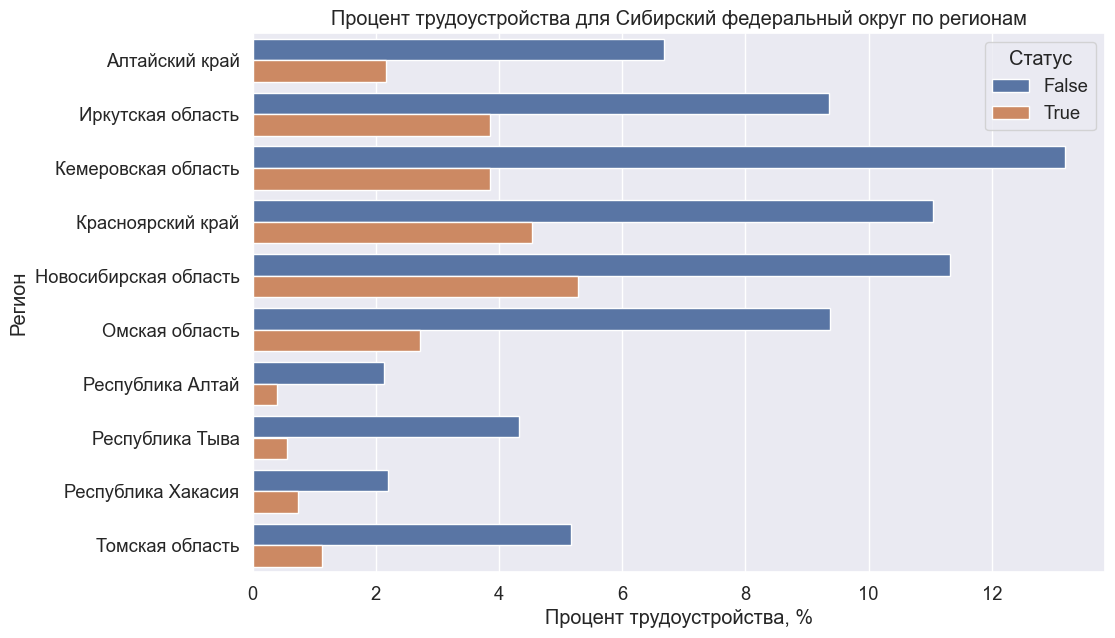

                                      region  find_new_job     sum    per
0                         Курганская область         False   31271   6.78
1                         Курганская область          True    8161   1.77
2                       Свердловская область         False  140160  30.38
3                       Свердловская область          True   33729   7.31
4                          Тюменская область         False   39612   8.59
5                          Тюменская область          True   14722   3.19
6   Ханты-Мансийский автономный округ - Югра         False   34609   7.50
7   Ханты-Мансийский автономный округ - Югра          True    8492   1.84
8                        Челябинская область         False  114450  24.81
9                        Челябинская область          True   24723   5.36
10           Ямало-Ненецкий автономный округ         False    8375   1.82
11           Ямало-Ненецкий автономный округ          True    2977   0.65


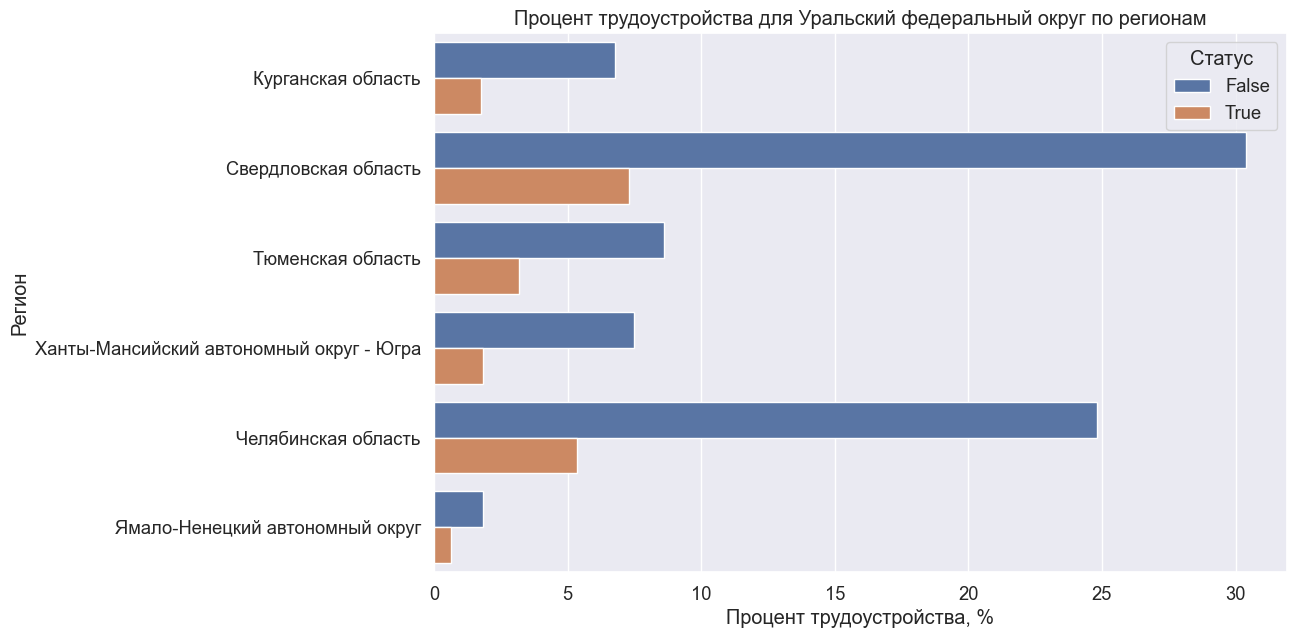

                  region  find_new_job     sum    per
0   Белгородская область         False   16122   1.55
1   Белгородская область          True   13147   1.26
2       Брянская область         False   28145   2.71
3       Брянская область          True    7370   0.71
4   Владимирская область         False   33117   3.19
5   Владимирская область          True   13620   1.31
6    Воронежская область         False   57489   5.53
7    Воронежская область          True   13469   1.30
8     Ивановская область         False   29052   2.79
9     Ивановская область          True    7222   0.69
10     Калужская область         False   15024   1.45
11     Калужская область          True    4522   0.44
12   Костромская область         False   18753   1.80
13   Костромская область          True    6152   0.59
14       Курская область         False   22588   2.17
15       Курская область          True    7800   0.75
16      Липецкая область         False   12016   1.16
17      Липецкая область    

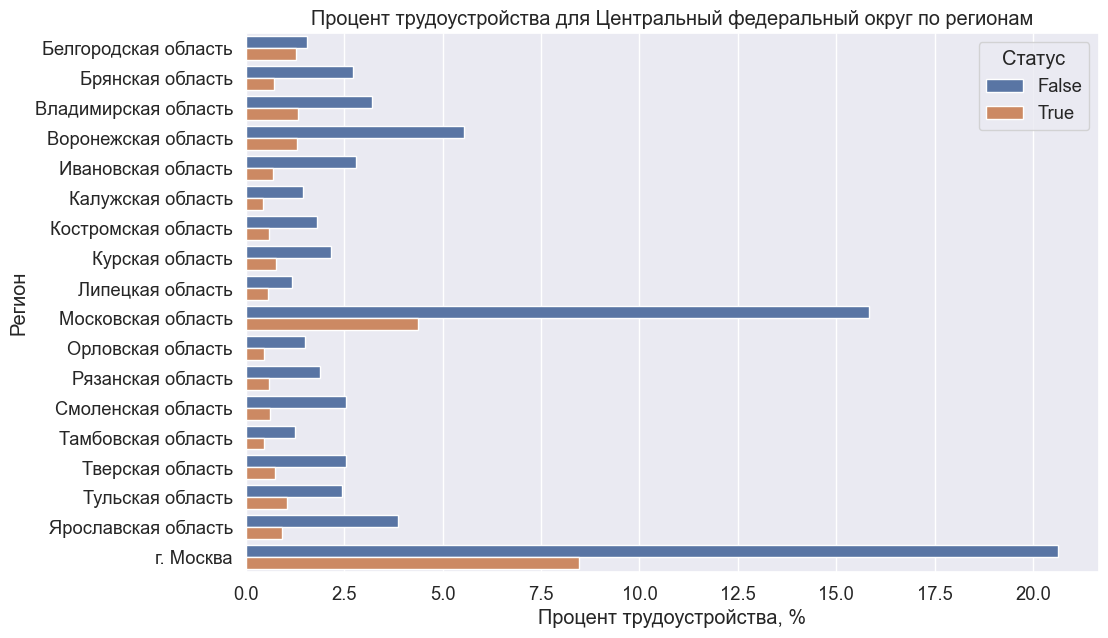

                        region  find_new_job     sum    per
0         Астраханская область         False   50330   8.24
1         Астраханская область          True    9734   1.59
2        Волгоградская область         False   54259   8.88
3        Волгоградская область          True   15778   2.58
4           Краснодарский край         False  169066  27.68
5           Краснодарский край          True   34602   5.67
6   Республика Адыгея (Адыгея)         False   15493   2.54
7   Республика Адыгея (Адыгея)          True    2678   0.44
8          Республика Калмыкия         False   12622   2.07
9          Республика Калмыкия          True    1882   0.31
10             Республика Крым         False   59551   9.75
11             Республика Крым          True   11921   1.95
12          Ростовская область         False  136056  22.28
13          Ростовская область          True   30749   5.03
14              г. Севастополь         False    4544   0.74
15              г. Севастополь          

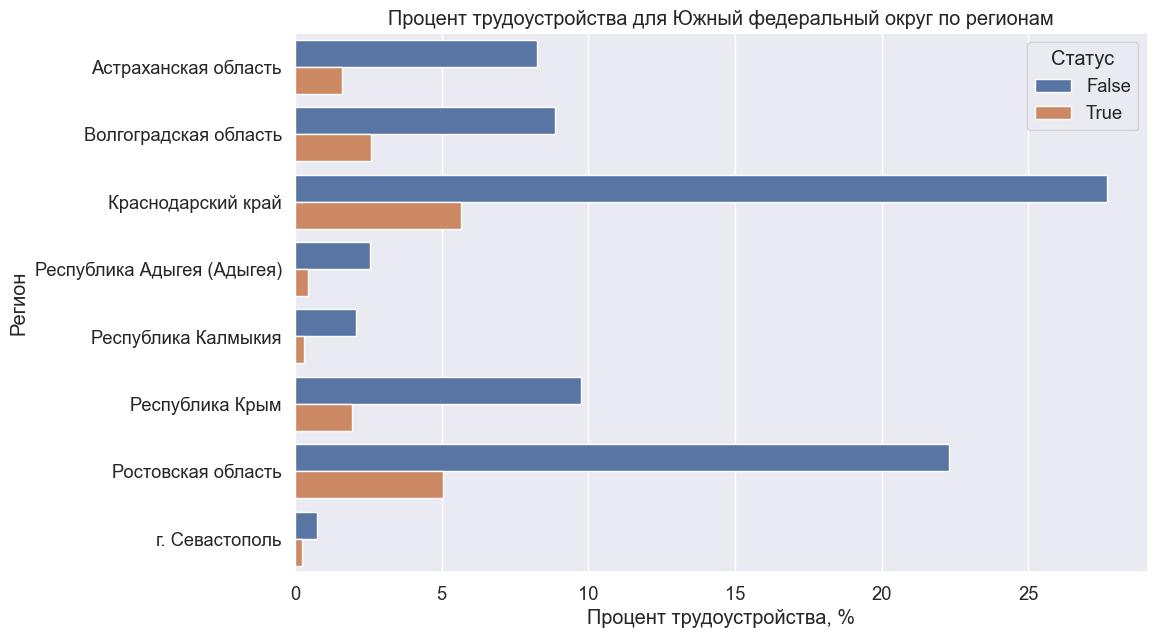

In [209]:
#напишем функцию, которая будет выводить столбчатые диаграммы для каждого федерального округа по регионам
for district in df['district'].unique():
    district_d = df[(df['district'] == district) & (df['year'] == 2020)]
    district_region_per_data = district_d.pivot_table(index = ['region', 'find_new_job'],
                                     values = 'count',
                                     aggfunc = 'sum').reset_index()
    district_region_per_data.columns = ['region', 'find_new_job', 'sum']
    total_district = district_d['count'].sum()
    district_region_per_data['per'] = (district_region_per_data['sum'] * 100 / total_district).round(2)
    print(district_region_per_data)
    sns.barplot(district_region_per_data, x = 'per', y = 'region', hue = 'find_new_job').set(title = f'Процент трудоустройства для {district} по регионам',
                                                              xlabel = 'Процент трудоустройства, %',
                                                              ylabel = 'Регион')
    plt.legend(title = 'Статус')
    plt.show()

В каждом регионе наблюдается тнеденция высокого числа безработных на 2020 год, соотношения различается в зависимости от количества проживающего населения в каждом из них. С большими проблемами сталкивается Северо-Кавказский федеральный округ, практически никто из обратившихся в центр занятости не смог найти работу. 

## Вывод: 

В результате исследования основных социально-демографических характеристик безработных и ситуацию в 2020 году, можно сделать следующие выводы. <br> 

Начавшаяся в 2020 году пандемия коронавируса и ограничения, связанные с ней, вызвали серьезные изменения в экономике России в целом, на рынке труда в частности. В том числе заставили правительство задуматься о усиление мер поддержки занятости и упрощения регистрации в службах занятости. <br>

В результате данные меры привели к повышению уровня регистрируемой безработицы, а причинами могли стать: потерявшие работу граждане в резултате пандемии или до неё, граждане, занятые в неформальном секторе, экономически неактивное население, впервые пытающиеся трудоустроится. Увеличение максимального размер пособия по безработице до уровня МРОТ (12,13 тыс. руб.), а минимального — до 4,5 тыс. руб. поспособствовало росту в апреле числа обращений на 80% по сравнению с предыдущем месяцем. Таким образом, пособие по безработице стало социальным инструментым, поддержавшим целую группу населения в период пандемии. 

Не смотря на то, что большинство граждан так и не смогли найти работу, пандемия поспособствовала выявления структурных проблем в каждом федеральном округе и отдельно в регионах. Самыми устойчивыми к кризису регионами сатли - Ямало-Ненецкий автономный округ, Ненецкий автономный округ, Чукотский автономный округ, город Севастополь. В этих регионах наименьшее количество граждан, обращались в службу занятости, а также процент трудоустройства обратившихся приблизительно равен проценту безрбаотных.  С большими проблемами сталкивается Северо-Кавказский федеральный округ, практически никто из обратившихся в центр занятости не смог найти работу, что объясняется струтутрынми проблемами: отсутствие крупных предприятий, низкая зарплата и высокий рост населения в горных районах Дагестана, для которого недостаточно рабочих мест.

Никогда не работавшие граждане испытвают трудности с трудоустройством. Значительное количество граждан никогда не приступали к трудовой деятельности, что указывает на серьезные системные пробелы в интеграции населения на рынок труда. Дискриминация по гендерному признаку осутсвует, ни женщины, ни мужчины не испытвают сложности с устройством на работу.